In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
import re
import seaborn as sns
import docx
import pylab
pd.set_option('display.max_rows', None)
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import scipy
import unicodeit
from collections import namedtuple

In [2]:
#In defining the reaction path you can substitute H energy with *H by all_mols_dict.get('13_H') ---> path_1_df['13_H'] - path_1_df['surf_energy']

plt.figure(figsize=(12,8))
sns.lineplot(x=path_1.index, y = '0_CuNi',data=path_1,label='CuNi',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '1_Ag_subCu',data=path_1,label='1_Ag_subCu',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '2_Au_subCu',data=path_1,label='2_Au_subCu',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '6_Pd_subNi',data=path_1,label='6_Pd_subNi',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '7_Pt_subNi',data=path_1,label='7_Pt_subNi',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '9_Fe_subNi',data=path_1,label='9_Fe_subNi',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '11_Pd_subCu',data=path_1,label='11_Pd_subCu',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '13_Ag_subNi',data=path_1,label='13_Ag_subNi',drawstyle='steps-pre')
sns.lineplot(x=path_1.index, y = '14_Au_subNi',data=path_1,label='14_Au_subNi',drawstyle='steps-pre')
#ax.set(xticklabels = (path_1_written))
plt.xticks(rotation=45)

In [3]:
def final_energy_qs(output,unit='ev'):
    output_file = open(output,'r')
    output_lines = output_file.readlines()
    for line in output_lines:
        if 'Final energy' in line:
            #print(line)
            final_E = float(line.split()[-2])
    output_file.close()
    if unit=='ry':
        return final_E  
    elif unit=='ev':
        return final_E * 13.605703976
    

In [4]:
#raw_df = pd.read_csv('./raw_df.csv')

In [5]:
#raw_df

In [6]:
all_mols_dict = {'0_N2': -40.27971791* 13.605703976,
 '2_N': -19.5429571333* 13.605703976,
 '1_H2': -2.3302438141* 13.605703976,
 '3_N2H': -41.2696631674* 13.605703976,
 '4_NHNH': -42.5083642397* 13.605703976,
 '5_NNH2': -42.4405833567* 13.605703976,
 '6_NNH3': -43.4810886190* 13.605703976,
 '7_NH2NH': -43.6855706118* 13.605703976,
 '8_N2H4': -44.9391323026* 13.605703976,
 '9_NH2': -22.3040791262* 13.605703976,
 '10_NH': -20.9151150555* 13.605703976,
 '11_NH3': -23.7121681317* 13.605703976,
 '12_NH2NH3': 0* 13.605703976,
 '13_H': -0.9233303917* 13.605703976}

In [7]:
df = pd.read_csv('./corrected_df.csv')

In [8]:
list(df[df.ad_site_number=='ad_site_1'].surf_energy)

[-325257.71160517656,
 -323786.3164802258,
 -321329.6146741825,
 -323291.3182206133,
 -323455.222624848,
 -325066.99482174136,
 -322467.9781963675,
 -324609.7110412068,
 -322152.9672299565]

In [9]:
df_adsE = pd.read_csv('./df_adsE.csv')
df_adsE

,system,ad_site_number,surf_energy,0_N2,2_N,3_N2H,4_NHNH,5_NNH2,6_NNH3,7_NH2NH,8_N2H4,9_NH2,10_NH,11_NH3,13_H
0,0_CuNi,ad_site_1,-325257.711605,-0.767459,-7.500567,-1.857682,-1.518407,-2.986011,-4.090311,-2.223105,-1.599692,-3.890020,-6.314894,-1.116656,-3.931919
1,0_CuNi,ad_site_2,-325257.711605,-0.884083,-7.500132,-2.129376,-1.549698,-2.607095,-4.090311,-2.230930,-1.139791,-3.656416,-5.863055,-1.213482,-3.770560
2,1_Ag_subCu,ad_site_1,-323786.316480,-0.754606,-8.833681,-1.845223,-1.472100,-3.472377,-4.336873,-2.259243,-1.602408,-3.307639,-6.764432,-1.093465,-4.023752
3,1_Ag_subCu,ad_site_2,-323786.316480,-0.754606,-7.644278,-2.162749,-1.509642,-2.711631,-4.336873,-1.812641,-0.899673,-3.542573,-6.056551,-1.093465,-3.821639
4,2_Au_subCu,ad_site_1,-321329.614674,-0.730240,-8.816798,-2.147021,-1.504719,-3.460111,-4.318504,-2.271743,-1.623596,-3.716703,-6.673041,-1.130210,-3.899331
5,2_Au_subCu,ad_site_2,-321329.614674,-0.853799,-7.521794,-2.147021,-1.541833,-2.660041,-4.318504,-1.832029,-1.553563,-3.502190,-5.956906,-1.234000,-3.802297
6,6_Pd_subNi,ad_site_2,-323291.318221,-0.875383,-7.481951,-2.005537,-0.967920,-2.573296,-4.141695,-2.455699,-1.230681,-3.492987,-5.865286,-1.211382,-3.685092
7,6_Pd_subNi,ad_site_1,-323291.318221,-0.759463,-7.474434,-2.005200,-1.487826,-2.545620,-3.945603,-2.494605,-1.230681,-3.180933,-5.696939,-1.122627,-3.764264
8,7_Pt_subNi,ad_site_1,-323455.222625,-0.846420,-7.725254,-2.126659,-0.978996,-2.746452,-4.031701,-2.460164,-1.288594,-3.637958,-5.762055,-1.228188,-3.743985
9,7_Pt_subNi,ad_site_2,-323455.222625,-0.727813,-7.630699,-2.336436,-1.521958,-2.466054,-4.031701,-2.501748,-1.454704,-3.210054,-5.712560,-1.132153,-3.756494


# Reaction Paths

In [10]:
path_1_ = ['0_N2','3_N2H','4_NHNH','7_NHNH2','8_N2H4','12_NH2NH3','11_NH3'] #associative
path_2_ = ['0_N2','3_N2H','5_NNH2','6_NNH3','2_N','10_NH','9_NH2','11_NH3'] #associative distal
path_3_ = ['2_N','10_NH','9_NH2','11_NH3'] #dissociative


In [11]:
df_dicts = {'ad_site_number':['0:path_1', '1:test_path1', '2:path_1_xticks', '3:path_1_steps','4:barriers_path1','5:graph_name'],
            'ad_site_1':{'path_1':[0,1,2,3,4,5],'path_2':[0,1,2,3,4,5],'path_3':[0,1,2,3,4,5],'HER':[0,1,2,3,4,5]},
            'ad_site_2':{'path_1':[0,1,2,3,4,5],'path_2':[0,1,2,3,4,5],'path_3':[0,1,2,3,4,5],'HER':[0,1,2,3,4,5]}}

In [12]:
site_number = 1

In [13]:
#path_1_written = [lev1: 'surface + N2_f + 3H2_f'
#                  lev2: '0_N2 + 3H2_f',
#                  lev3: '3_N2H + 2H2_f + H_f', ##????,
#                  lev4: '4_NHNH + 2H2_f',
#                  lev5:'7_NHNH2 + H2 + H_f',
#                  lev6: '8_N2H4 + H2_f',
#                  lev7: '12_NH2NH3 + H_f',
#                  lev8: '11_NH3 + NH3_f']
#path_1_df
path_1_written = ['* + N2 + 3H2',
                  '*N2 + 3H2',
                  '*N2H + 2H2 + *H',
                  '*NHNH + 2H2',
                  '*NHNH2 + H2 + H',
                  '*N2H4 + H2',
                  '*NH2 + NH3 + H',
                  '*NH3 + NH3',
                  '2NH3 + *']

path_1_df = df.copy()
path_1_df = path_1_df[path_1_df['ad_site_number'] == f'ad_site_{site_number}'] 


path_1_df['lev1'] = path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3 -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev2'] = path_1_df['0_N2'] + all_mols_dict.get('1_H2')*3 -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev3'] = path_1_df['3_N2H'] + all_mols_dict.get('1_H2')*2 + (all_mols_dict.get('1_H2')*0.5) -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev4'] = path_1_df['4_NHNH'] + all_mols_dict.get('1_H2')*2 -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev5'] = path_1_df['7_NH2NH'] + all_mols_dict.get('1_H2') + (all_mols_dict.get('1_H2')*0.5) -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev6'] = path_1_df['8_N2H4'] + all_mols_dict.get('1_H2') -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev7'] = path_1_df['12_NH2NH3'] + (all_mols_dict.get('1_H2')*0.5) -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev8'] = path_1_df['11_NH3'] + all_mols_dict.get('11_NH3') -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)
path_1_df['lev9'] = all_mols_dict.get('11_NH3')*2 + path_1_df['surf_energy'] -(path_1_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_1 = path_1_df[['system','lev1', 'lev2', 'lev3', 'lev4', 'lev5',
       'lev6', 'lev7', 'lev8','lev9']]
path_1 = path_1.transpose()
if site_number==1:
    path_1 = path_1.rename(columns={0:'0_CuNi',2:'1_Ag_subCu',4:'2_Au_subCu',7:'6_Pd_subNi',8:'7_Pt_subNi',11:'9_Fe_subNi', 13:'11_Pd_subCu',
                 14:'13_Ag_subNi',17:'14_Au_subNi'})
elif site_number == 2:
    path_1 = path_1.rename(columns={1:'0_CuNi',3:'1_Ag_subCu',5:'2_Au_subCu',6:'6_Pd_subNi',9:'7_Pt_subNi',10:'9_Fe_subNi', 12:'11_Pd_subCu',
                 15:'13_Ag_subNi',16:'14_Au_subNi'})
path_1.drop('system',axis=0,inplace=True)

path_1['steps'] = ['* + N2 + 3H2',
                  '*N2 + 3H2',
                  '*N2H + 2H2 + H',
                  '*NHNH + 2H2',
                  '*NHNH2 + H2 + H',
                  '*N2H4 + H2',
                  '*NH2NH3 + H',
                  '*NH3 + NH3',
                  '2NH3 + *']

path_1 = path_1[['steps','0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']]

path_1.reset_index(inplace=True)
path_1.drop('index',inplace=True,axis=1)
path_1.index = path_1.index + 1

test_path1 = path_1.copy()
indices = range(1,10)
for ind in indices:
    test_path1 = test_path1.append(test_path1.loc[[ind]*(5-1)]).sort_index()
test_path1.reset_index(inplace=True)
test_path1.drop('index',inplace=True,axis=1)

#path_1
#test_path1

path_1_xticks = []
path_1_steps = ['* + N2',
                  '*N2',
                  '*N2H',
                  '*NHNH',
                  '*NHNH2',
                  '*N2H4',
                  '*NH2NH3',
                  '*NH3 + NH3',
                  '2NH3 + *']

for i in path_1_steps:
    path_1_xticks.append('')
    path_1_xticks.append('')
    path_1_xticks.append(i)
    path_1_xticks.append('')
    path_1_xticks.append('')
    
barriers_path1 = pd.DataFrame()

for ind in path_1.index.tolist()[1:]:
    barriers_path1[f'{path_1_steps[ind - 1]}'] = path_1[['0_CuNi', '1_Ag_subCu', '2_Au_subCu', '6_Pd_subNi',
       '7_Pt_subNi', '9_Fe_subNi', '11_Pd_subCu', '13_Ag_subNi',
       '14_Au_subNi']].loc[ind] - path_1[['0_CuNi', '1_Ag_subCu', '2_Au_subCu', '6_Pd_subNi',
       '7_Pt_subNi', '9_Fe_subNi', '11_Pd_subCu', '13_Ag_subNi',
       '14_Au_subNi']].loc[ind-1]

#df_dicts = {'ad_site_1':[path_1, test_path1, path_1_xticks, path_1_steps,barriers_path1 ]
df_dicts[f'ad_site_{site_number}']['path_1'][0] =  path_1
df_dicts[f'ad_site_{site_number}']['path_1'][1] =  test_path1
df_dicts[f'ad_site_{site_number}']['path_1'][2] =  path_1_xticks
df_dicts[f'ad_site_{site_number}']['path_1'][3] =  path_1_steps
df_dicts[f'ad_site_{site_number}']['path_1'][4] =  barriers_path1
df_dicts[f'ad_site_{site_number}']['path_1'][5] =  'Associative alternating'

path_1

,steps,0_CuNi,1_Ag_subCu,2_Au_subCu,6_Pd_subNi,7_Pt_subNi,9_Fe_subNi,11_Pd_subCu,13_Ag_subNi,14_Au_subNi
1,* + N2 + 3H2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,*N2 + 3H2,-0.767459,-0.754606,-0.73024,-0.759463,-0.84642,-0.877121,-0.847855,-0.774378,-0.768534
3,*N2H + 2H2 + H,0.52572,0.538179,0.236381,0.378202,0.256742,0.288819,0.167727,0.258165,-0.462557
4,*NHNH + 2H2,-0.136102,-0.089795,-0.122413,-0.10552,0.40331,-0.156816,-0.137238,-0.123393,-0.139525
5,*NHNH2 + H2 + H,-1.005218,-1.041356,-1.053855,-1.276717,-1.242277,-1.267897,-0.778488,-0.861622,-0.83803
6,*N2H4 + H2,-1.585089,-1.587806,-1.608994,-1.216079,-1.273991,-1.05945,-1.110361,-1.424744,-1.47391
7,*NH2NH3 + H,-2.7947,-2.813232,-2.830908,-2.507345,-3.059633,-3.0197,-2.989849,-2.651533,-2.601715
8,*NH3 + NH3,-3.210396,-3.187204,-3.22395,-3.216367,-3.321928,-3.292236,-3.300064,-3.202832,-3.251552
9,2NH3 + *,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374


path_1.to_csv(f'path_1_site{site_number}.csv',index=False)
test_path1.to_csv(f'multip_path_1_site{site_number}.csv',index=False)

In [14]:
#path_2_written = [lev1: 'surface + N2_f + 3H2_f'
#                  lev2: '0_N2 + 3H2_f',
#                  lev3: '3_N2H + 2H2_f + H_f', ##????,
#                  lev4: '5_NNH2 + 2H2_f',
#                  lev5:'6_NNH3 + H2 + H_f',
#                  lev6: '2_N + H2_f + H_f + NH3_f',
#                  lev7: '10_NH + H2_f + NH3_f',
#                  lev8: '9_NH2 + H_f + NH3_f
#                  lev9:  '11_NH3' + NH3_f,
#                  lev10:  2*'11_NH3' + *]
                  

path_2_written = ['* + N2 + 3H2',
                  '*N2 + 3H2',
                  '*N2H + 2H2 + H',
                  '*NNH2 + 2H2',
                  '*NNH3 + H2 + H',
                  '*N + H2 + H + NH3',
                  '*NH + H2 + NH3',
                  '*NH2 + H + NH3',
                  '*NH3 + NH3',
                  '2NH3 + *']

#path_2_df
path_2_df = df.copy()
path_2_df = path_2_df[path_2_df['ad_site_number'] == f'ad_site_{site_number}']




path_2_df['lev1'] = path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3 -(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev2'] = path_2_df['0_N2'] + all_mols_dict.get('1_H2')*3 -(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev3'] = path_2_df['3_N2H'] + all_mols_dict.get('1_H2')*2 + (all_mols_dict.get('1_H2')*0.5) -(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev4'] = path_2_df['5_NNH2'] + all_mols_dict.get('1_H2')*2 -(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev5'] = path_2_df['6_NNH3'] + all_mols_dict.get('1_H2') + (all_mols_dict.get('1_H2')*0.5) -(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev6'] = path_2_df['2_N'] + all_mols_dict.get('1_H2') + (all_mols_dict.get('1_H2')*0.5) + all_mols_dict.get('11_NH3')-(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev7'] = path_2_df['10_NH'] + all_mols_dict.get('1_H2') + all_mols_dict.get('11_NH3')-(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev8'] = path_2_df['9_NH2'] + (all_mols_dict.get('1_H2')*0.5) + all_mols_dict.get('11_NH3')-(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev9'] = path_2_df['11_NH3'] +  all_mols_dict.get('11_NH3')-(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)

path_2_df['lev10'] = 2*all_mols_dict.get('11_NH3') + path_2_df['surf_energy']-(path_2_df['surf_energy'] + all_mols_dict.get('0_N2') + all_mols_dict.get('1_H2')*3)



path_2 = path_2_df[['system','lev1', 'lev2', 'lev3', 'lev4', 'lev5','lev6', 'lev7', 'lev8','lev9','lev10']]
path_2 = path_2.transpose()
if site_number==1:
    path_2 = path_2.rename(columns={0:'0_CuNi',2:'1_Ag_subCu',4:'2_Au_subCu',7:'6_Pd_subNi',8:'7_Pt_subNi',11:'9_Fe_subNi', 13:'11_Pd_subCu',
                 14:'13_Ag_subNi',17:'14_Au_subNi'})
elif site_number == 2:
    path_2 = path_2.rename(columns={1:'0_CuNi',3:'1_Ag_subCu',5:'2_Au_subCu',6:'6_Pd_subNi',9:'7_Pt_subNi',10:'9_Fe_subNi', 12:'11_Pd_subCu',
                 15:'13_Ag_subNi',16:'14_Au_subNi'})
path_2.drop('system',axis=0,inplace=True)

path_2['steps'] = ['* + N2 + 3H2',
                  '*N2 + 3H2',
                  '*N2H + 2H2 + H',
                  '*NNH2 + 2H2',
                  '*NNH3 + H2 + H',
                  '*N + H2 + H + NH3',
                  '*NH + H2 + NH3',
                  '*NH2 + H + NH3',
                  '*NH3 + NH3',
                  '2NH3 + *']

path_2 = path_2[['steps','0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']]

path_2.reset_index(inplace=True)
path_2.drop('index',inplace=True,axis=1)
path_2.index = path_2.index + 1

test_path2 = path_2.copy()
indices = range(1,11)
for ind in indices:
    test_path2 = test_path2.append(test_path2.loc[[ind]*(5-1)]).sort_index()
test_path2.reset_index(inplace=True)
test_path2.drop('index',inplace=True,axis=1)

path_2_xticks = []
path_2_steps = ['* + N2',
                  '*N2',
                  '*N2H',
                  '*NNH2',
                  '*NNH3',
                  '*N + NH3',
                  '*NH + NH3',
                  '*NH2 + NH3',
                  '*NH3 + NH3',
                  '2NH3 + *']

for i in path_2_steps:
    path_2_xticks.append('')
    path_2_xticks.append('')
    path_2_xticks.append(i)
    path_2_xticks.append('')
    path_2_xticks.append('')

#test_path2
#path_2
barriers_path2 = pd.DataFrame()

for ind in path_2.index.tolist()[1:]:
    barriers_path2[f'{path_2_steps[ind - 1]}'] = path_2[['0_CuNi', '1_Ag_subCu', '2_Au_subCu', '6_Pd_subNi',
       '7_Pt_subNi', '9_Fe_subNi', '11_Pd_subCu', '13_Ag_subNi',
       '14_Au_subNi']].loc[ind] - path_2[['0_CuNi', '1_Ag_subCu', '2_Au_subCu', '6_Pd_subNi',
       '7_Pt_subNi', '9_Fe_subNi', '11_Pd_subCu', '13_Ag_subNi',
       '14_Au_subNi']].loc[ind-1]

#df_dicts = {'ad_site_1':[path_1, test_path1, path_1_xticks, path_1_steps,barriers_path1 ]
df_dicts[f'ad_site_{site_number}']['path_2'][0] = path_2
df_dicts[f'ad_site_{site_number}']['path_2'][1] =  test_path2
df_dicts[f'ad_site_{site_number}']['path_2'][2] =  path_2_xticks
df_dicts[f'ad_site_{site_number}']['path_2'][3] =  path_2_steps
df_dicts[f'ad_site_{site_number}']['path_2'][4] =  barriers_path2
df_dicts[f'ad_site_{site_number}']['path_2'][5] =  'Associative distal'

path_2

,steps,0_CuNi,1_Ag_subCu,2_Au_subCu,6_Pd_subNi,7_Pt_subNi,9_Fe_subNi,11_Pd_subCu,13_Ag_subNi,14_Au_subNi
1,* + N2 + 3H2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,*N2 + 3H2,-0.767459,-0.754606,-0.73024,-0.759463,-0.84642,-0.877121,-0.847855,-0.774378,-0.768534
3,*N2H + 2H2 + H,0.52572,0.538179,0.236381,0.378202,0.256742,0.288819,0.167727,0.258165,-0.462557
4,*NNH2 + 2H2,-0.681499,-1.167865,-1.155599,-0.241108,-0.44194,-0.23929,-0.367949,-0.78105,-0.672042
5,*NNH3 + H2 + H,-0.090302,-0.336864,-0.318495,0.054406,-0.031692,-0.065993,-0.037068,-0.646062,-0.622944
6,*N + H2 + H + NH3,-0.426168,-1.759281,-1.742399,-0.400035,-0.650855,-0.400655,-0.454805,-1.108062,-1.039454
7,*NH + H2 + NH3,-2.057366,-2.506903,-2.415512,-1.43941,-1.504526,-1.598385,-1.548124,-2.082635,-2.023061
8,*NH2 + H + NH3,-2.678021,-2.095641,-2.504704,-1.968934,-2.42596,-2.44478,-2.336189,-2.705919,-2.718208
9,*NH3 + NH3,-3.210396,-3.187204,-3.22395,-3.216367,-3.321928,-3.292236,-3.300064,-3.202832,-3.251552
10,2NH3 + *,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374,-2.09374


path_2.to_csv(f'path_2_site{site_number}.csv',index=False)
test_path2.to_csv(f'multip_path_2_site{site_number}.csv',index=False)

In [15]:
#path_3_written = [lev1: 'surface + N2_f + 3H2_f'
#                  lev2: '0_N2 + 3H2_f',
#                  lev3: '3_N2H + 2H2_f + H_f', ##????,
#                  lev4: '5_NNH2 + 2H2_f',
#                  lev5:'6_NNH3 + H2 + H_f',
#                  lev6: '2_N + H2_f + H_f + NH3_f',
#                  lev7: '10_NH + H2_f + NH3_f',
#                  lev8: '9_NH2 + H_f + NH3_f
#                  lev9:  '11_NH3' + NH3_f,
#                  lev10:  2*'11_NH3' + *]
                  
path_3_written = ['1/2N2 + 3/2H2 + *',
                  'N* - * + 3/2H2',
                  'NH* - * + H2',
                  'NH2* - * + 1/2H2',
                  'NH3* - *',
                  'NH3 + * ']

#path_3_df
path_3_df = df.copy()
path_3_df = path_3_df[path_3_df['ad_site_number'] == f'ad_site_{site_number}']




path_3_df['lev1'] =  path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5) -(path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5))

path_3_df['lev2'] = path_3_df['2_N'] + (all_mols_dict.get('1_H2')*1.5) -(path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5))

path_3_df['lev3'] = path_3_df['10_NH'] + all_mols_dict.get('1_H2')-(path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5))

path_3_df['lev4'] = path_3_df['9_NH2']+ (all_mols_dict.get('1_H2')*0.5) - (path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5))

path_3_df['lev5'] = path_3_df['11_NH3'] -(path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5))

path_3_df['lev6'] = all_mols_dict.get('11_NH3') + path_3_df['surf_energy']-(path_3_df['surf_energy'] + (all_mols_dict.get('0_N2')*0.5) + (all_mols_dict.get('1_H2')*1.5))




path_3 = path_3_df[['system','lev1', 'lev2', 'lev3', 'lev4', 'lev5',
       'lev6']]
path_3 = path_3.transpose()
if site_number==1:
    path_3 = path_3.rename(columns={0:'0_CuNi',2:'1_Ag_subCu',4:'2_Au_subCu',7:'6_Pd_subNi',8:'7_Pt_subNi',11:'9_Fe_subNi', 13:'11_Pd_subCu',
                 14:'13_Ag_subNi',17:'14_Au_subNi'})
elif site_number == 2:
    path_3 = path_3.rename(columns={1:'0_CuNi',3:'1_Ag_subCu',5:'2_Au_subCu',6:'6_Pd_subNi',9:'7_Pt_subNi',10:'9_Fe_subNi', 12:'11_Pd_subCu',
                 15:'13_Ag_subNi',16:'14_Au_subNi'})

path_3.drop('system',axis=0,inplace=True)

path_3['steps'] = ['N2 + 3H2 + *',
                  '2N* - * + 3H2',
                  '2NH* - * + 2H2',
                  '2NH2* - * + H2',
                  '2NH3* - *',
                  '2NH3 + * ']

path_3 = path_3[['steps','0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']]

path_3.reset_index(inplace=True)
path_3.drop('index',inplace=True,axis=1)
path_3.index = path_3.index + 1


test_path3 = path_3.copy()
indices = range(1,7)
for ind in indices:
    test_path3 = test_path3.append(test_path3.loc[[ind]*(5-1)]).sort_index()
test_path3.reset_index(inplace=True)
test_path3.drop('index',inplace=True,axis=1)
#test_path3
#path_3

path_3_xticks = []
path_3_steps = ['* + N2',
                  '2N*',
                  '2NH*',
                  '2NH2*',
                  '2NH3*',
                  '2NH3 + * ']
    
for i in path_3_steps:
    path_3_xticks.append('')
    path_3_xticks.append('')
    path_3_xticks.append(i)
    path_3_xticks.append('')
    path_3_xticks.append('')
    
barriers_path3 = pd.DataFrame()

for ind in path_3.index.tolist()[1:]:
    barriers_path3[f'{path_3_steps[ind-1]}'] = path_3[['0_CuNi', '1_Ag_subCu', '2_Au_subCu', '6_Pd_subNi',
       '7_Pt_subNi', '9_Fe_subNi', '11_Pd_subCu', '13_Ag_subNi',
       '14_Au_subNi']].loc[ind] - path_3[['0_CuNi', '1_Ag_subCu', '2_Au_subCu', '6_Pd_subNi',
       '7_Pt_subNi', '9_Fe_subNi', '11_Pd_subCu', '13_Ag_subNi',
       '14_Au_subNi']].loc[ind-1]

#df_dicts = {'ad_site_1':[path_1, test_path1, path_1_xticks, path_1_steps,barriers_path1 ]
df_dicts[f'ad_site_{site_number}']['path_3'][0] = path_3
df_dicts[f'ad_site_{site_number}']['path_3'][1] =  test_path3
df_dicts[f'ad_site_{site_number}']['path_3'][2] =  path_3_xticks
df_dicts[f'ad_site_{site_number}']['path_3'][3] =  path_3_steps
df_dicts[f'ad_site_{site_number}']['path_3'][4] =  barriers_path3
df_dicts[f'ad_site_{site_number}']['path_3'][5] =  'Dissociative'

path_3

,steps,0_CuNi,1_Ag_subCu,2_Au_subCu,6_Pd_subNi,7_Pt_subNi,9_Fe_subNi,11_Pd_subCu,13_Ag_subNi,14_Au_subNi
1,N2 + 3H2 + *,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2N* - * + 3H2,0.620702,-0.712411,-0.695529,0.646835,0.396015,0.646214,0.592065,-0.061192,0.007416
3,2NH* - * + 2H2,-1.010496,-1.460033,-1.368642,-0.392541,-0.457656,-0.551515,-0.501254,-1.035765,-0.976191
4,2NH2* - * + H2,-1.631151,-1.048771,-1.457834,-0.922064,-1.37909,-1.39791,-1.289319,-1.659049,-1.671338
5,2NH3* - *,-2.163526,-2.140334,-2.17708,-2.169497,-2.275058,-2.245366,-2.253194,-2.155962,-2.204682
6,2NH3 + *,-1.04687,-1.04687,-1.04687,-1.04687,-1.04687,-1.04687,-1.04687,-1.04687,-1.04687


In [16]:
#site_number = 2
HER_written = ['* + H+ + e-',
                  '*H',
                  '* + (1/2)H2']

HER_df = df.copy()
HER_df = HER_df[HER_df['ad_site_number'] == f'ad_site_{site_number}'] 

#H2 path
HER_df['lev1'] = HER_df['surf_energy'] + all_mols_dict.get('1_H2')*1/2 - (HER_df['surf_energy'] + all_mols_dict.get('1_H2')*1/2)
HER_df['lev2'] = HER_df['13_H'] -(HER_df['surf_energy'] + all_mols_dict.get('1_H2')*1/2)
HER_df['lev3'] = HER_df['surf_energy'] + all_mols_dict.get('1_H2')*1/2 -(HER_df['surf_energy'] + all_mols_dict.get('1_H2')*1/2)



HER = HER_df[['system','lev1', 'lev2', 'lev3']]
HER = HER.transpose()

if site_number==1:
    HER = HER.rename(columns={0:'0_CuNi',
                              2:'1_Ag_subCu',
                              4:'2_Au_subCu',
                              7:'6_Pd_subNi',
                              8:'7_Pt_subNi',
                              11:'9_Fe_subNi', 
                              13:'11_Pd_subCu',
                              14:'13_Ag_subNi',
                              17:'14_Au_subNi'})
elif site_number == 2:
    HER = HER.rename(columns={1:'0_CuNi',
                              3:'1_Ag_subCu',
                              5:'2_Au_subCu',
                              6:'6_Pd_subNi',
                              9:'7_Pt_subNi',
                              10:'9_Fe_subNi', 
                              12:'11_Pd_subCu',
                              15:'13_Ag_subNi',
                              16:'14_Au_subNi'})
#print(HER)
HER.drop('system',axis=0,inplace=True)

HER['steps'] = ['* + H+ + e-',
                  '*H',
                  '* + (1/2)H2']

HER = HER[['steps',
           '0_CuNi',
           '1_Ag_subCu',
           '2_Au_subCu',
           '6_Pd_subNi',
           '7_Pt_subNi',
           '9_Fe_subNi', 
           '11_Pd_subCu',
           '13_Ag_subNi',
           '14_Au_subNi']]

HER.reset_index(inplace=True)
HER.drop('index',inplace=True,axis=1)
HER.index = HER.index + 1

test_HER = HER.copy()
indices = range(1,4)
for ind in indices:
    test_HER = test_HER.append(test_HER.loc[[ind]*(5-1)]).sort_index()
test_HER.reset_index(inplace=True)
test_HER.drop('index',inplace=True,axis=1)

HER_xticks = []
HER_steps = ['* + H+ + e-',
                  '*H',
                  '* + (1/2)H2']

for i in HER_steps:
    HER_xticks.append('')
    HER_xticks.append('')
    HER_xticks.append(i)
    HER_xticks.append('')
    HER_xticks.append('')
    
barriers_HER = pd.DataFrame()

for ind in HER.index.tolist()[1:]:
    barriers_HER[f'{HER_steps[ind - 1]}'] = HER[['0_CuNi', 
                                                 '1_Ag_subCu', 
                                                 '2_Au_subCu', 
                                                 '6_Pd_subNi',
                                                 '7_Pt_subNi', 
                                                 '9_Fe_subNi',
                                                 '11_Pd_subCu', 
                                                 '13_Ag_subNi',
                                                 '14_Au_subNi']].loc[ind] - HER[['0_CuNi',
                                                                                    '1_Ag_subCu',
                                                                                    '2_Au_subCu',
                                                                                    '6_Pd_subNi',
                                                                                    '7_Pt_subNi', 
                                                                                    '9_Fe_subNi', 
                                                                                    '11_Pd_subCu', 
                                                                                    '13_Ag_subNi',
                                                                                    '14_Au_subNi']].loc[ind-1]


df_dicts[f'ad_site_{site_number}']['HER'][0] =  HER
df_dicts[f'ad_site_{site_number}']['HER'][1] =  test_HER
df_dicts[f'ad_site_{site_number}']['HER'][2] =  HER_xticks
df_dicts[f'ad_site_{site_number}']['HER'][3] =  HER_steps
df_dicts[f'ad_site_{site_number}']['HER'][4] =  barriers_HER
df_dicts[f'ad_site_{site_number}']['HER'][5] =  'Hydrogen'

HER

,steps,0_CuNi,1_Ag_subCu,2_Au_subCu,6_Pd_subNi,7_Pt_subNi,9_Fe_subNi,11_Pd_subCu,13_Ag_subNi,14_Au_subNi
1,* + H+ + e-,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,*H,-0.642175,-0.734008,-0.609587,-0.47452,-0.454242,-0.483422,-0.507111,-0.644583,-0.734733
3,* + (1/2)H2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


path_3.to_csv(f'path_3_site{site_number}.csv',index=False)
test_path3.to_csv(f'multip_path_3_site{site_number}.csv',index=False)

In [17]:
path_1_ = ['0_N2','3_N2H','4_NHNH','7_NHNH2','8_N2H4','12_NH2NH3','11_NH3'] #associative 
path_2_ = ['0_N2','3_N2H','5_NNH2','6_NNH3','2_N','10_NH','9_NH2','11_NH3'] #associative distal
path_3_ = ['2_N','10_NH','9_NH2','11_NH3'] #dissociative


In [18]:
df_p1_s1 = df_dicts[f'ad_site_1']['path_1'][4]
df_p1_s2 = df_dicts[f'ad_site_2']['path_1'][4]

df_p2_s1 = df_dicts[f'ad_site_1']['path_2'][4]
df_p2_s2 = df_dicts[f'ad_site_2']['path_2'][4]

df_p3_s1 = df_dicts[f'ad_site_1']['path_3'][4]
df_p3_s2 = df_dicts[f'ad_site_2']['path_3'][4]

In [19]:
def find_3top_barrier(df):
    systems = []
    first_bar_cols = []
    first_bar_vals = []
    sec_bar_cols = []
    sec_bar_vals = []
    third_bar_cols = []
    third_bar_vals = []
    new_df = pd.DataFrame()
    cols = list(df.columns)
    for i in range(len(df)):
        name = df.iloc[i].name
        vals = list(df.iloc[i])
        bar_col_vals = list(zip(cols,vals))
        bar_col_vals = sorted(bar_col_vals, key=lambda x: x[1],reverse=True)
        systems.append(name)
        first_bar_cols.append(bar_col_vals[0][0])
        first_bar_vals.append(bar_col_vals[0][1])
        
        sec_bar_cols.append(bar_col_vals[1][0])
        sec_bar_vals.append(bar_col_vals[1][1])
        
        third_bar_cols.append(bar_col_vals[2][0])
        third_bar_vals.append(bar_col_vals[2][1])
        
    new_df['system'] = systems
    new_df['first barrier'] = first_bar_cols
    new_df['first barrier val'] = first_bar_vals
    new_df['second barrier'] = sec_bar_cols
    new_df['second barrier val'] = sec_bar_vals
    new_df['third barrier'] = third_bar_cols
    new_df['third barrier val'] = third_bar_vals
    return new_df
            

In [20]:
find_3top_barrier(df_p1_s1).sort_values(by='second barrier val')

,system,first barrier,first barrier val,second barrier,second barrier val,third barrier,third barrier val
8,14_Au_subNi,2NH3 + *,1.157812,*NHNH,0.323032,*N2H,0.305977
2,2_Au_subCu,2NH3 + *,1.130210,*N2H,0.966621,*NHNH,-0.358794
6,11_Pd_subCu,2NH3 + *,1.206324,*N2H,1.015582,*NHNH,-0.304965
7,13_Ag_subNi,2NH3 + *,1.109092,*N2H,1.032544,*NHNH,-0.381558
1,1_Ag_subCu,*N2H,1.292785,2NH3 + *,1.093465,*NH3 + NH3,-0.373972
4,7_Pt_subNi,2NH3 + *,1.228188,*N2H,1.103162,*NHNH,0.146567
0,0_CuNi,*N2H,1.293179,2NH3 + *,1.116656,*NH3 + NH3,-0.415696
3,6_Pd_subNi,*N2H,1.137665,2NH3 + *,1.122627,*N2H4,0.060638
5,9_Fe_subNi,2NH3 + *,1.198496,*N2H,1.165940,*N2H4,0.208447


In [21]:
find_3top_barrier(df_p2_s1).sort_values(by='second barrier val')

,system,first barrier,first barrier val,second barrier,second barrier val,third barrier,third barrier val
8,14_Au_subNi,2NH3 + *,1.157812,*N2H,0.305977,*NNH3,0.049098
2,2_Au_subCu,2NH3 + *,1.130210,*N2H,0.966621,*NNH3,0.837104
6,11_Pd_subCu,2NH3 + *,1.206324,*N2H,1.015582,*NNH3,0.330881
7,13_Ag_subNi,2NH3 + *,1.109092,*N2H,1.032544,*NNH3,0.134988
1,1_Ag_subCu,*N2H,1.292785,2NH3 + *,1.093465,*NNH3,0.831001
4,7_Pt_subNi,2NH3 + *,1.228188,*N2H,1.103162,*NNH3,0.410248
0,0_CuNi,*N2H,1.293179,2NH3 + *,1.116656,*NNH3,0.591196
3,6_Pd_subNi,*N2H,1.137665,2NH3 + *,1.122627,*NNH3,0.295514
5,9_Fe_subNi,2NH3 + *,1.198496,*N2H,1.165940,*NNH3,0.173297


In [22]:
find_3top_barrier(df_p3_s1).sort_values(by='second barrier val')

,system,first barrier,first barrier val,second barrier,second barrier val,third barrier,third barrier val
2,2_Au_subCu,2NH3 + *,1.130210,2NH2*,-0.089192,2NH*,-0.673113
7,13_Ag_subNi,2NH3 + *,1.109092,2N*,-0.061192,2NH3*,-0.496913
8,14_Au_subNi,2NH3 + *,1.157812,2N*,0.007416,2NH3*,-0.533345
4,7_Pt_subNi,2NH3 + *,1.228188,2N*,0.396015,2NH*,-0.853671
1,1_Ag_subCu,2NH3 + *,1.093465,2NH2*,0.411263,2N*,-0.712411
6,11_Pd_subCu,2NH3 + *,1.206324,2N*,0.592065,2NH2*,-0.788065
0,0_CuNi,2NH3 + *,1.116656,2N*,0.620702,2NH3*,-0.532375
5,9_Fe_subNi,2NH3 + *,1.198496,2N*,0.646214,2NH2*,-0.846395
3,6_Pd_subNi,2NH3 + *,1.122627,2N*,0.646835,2NH2*,-0.529523


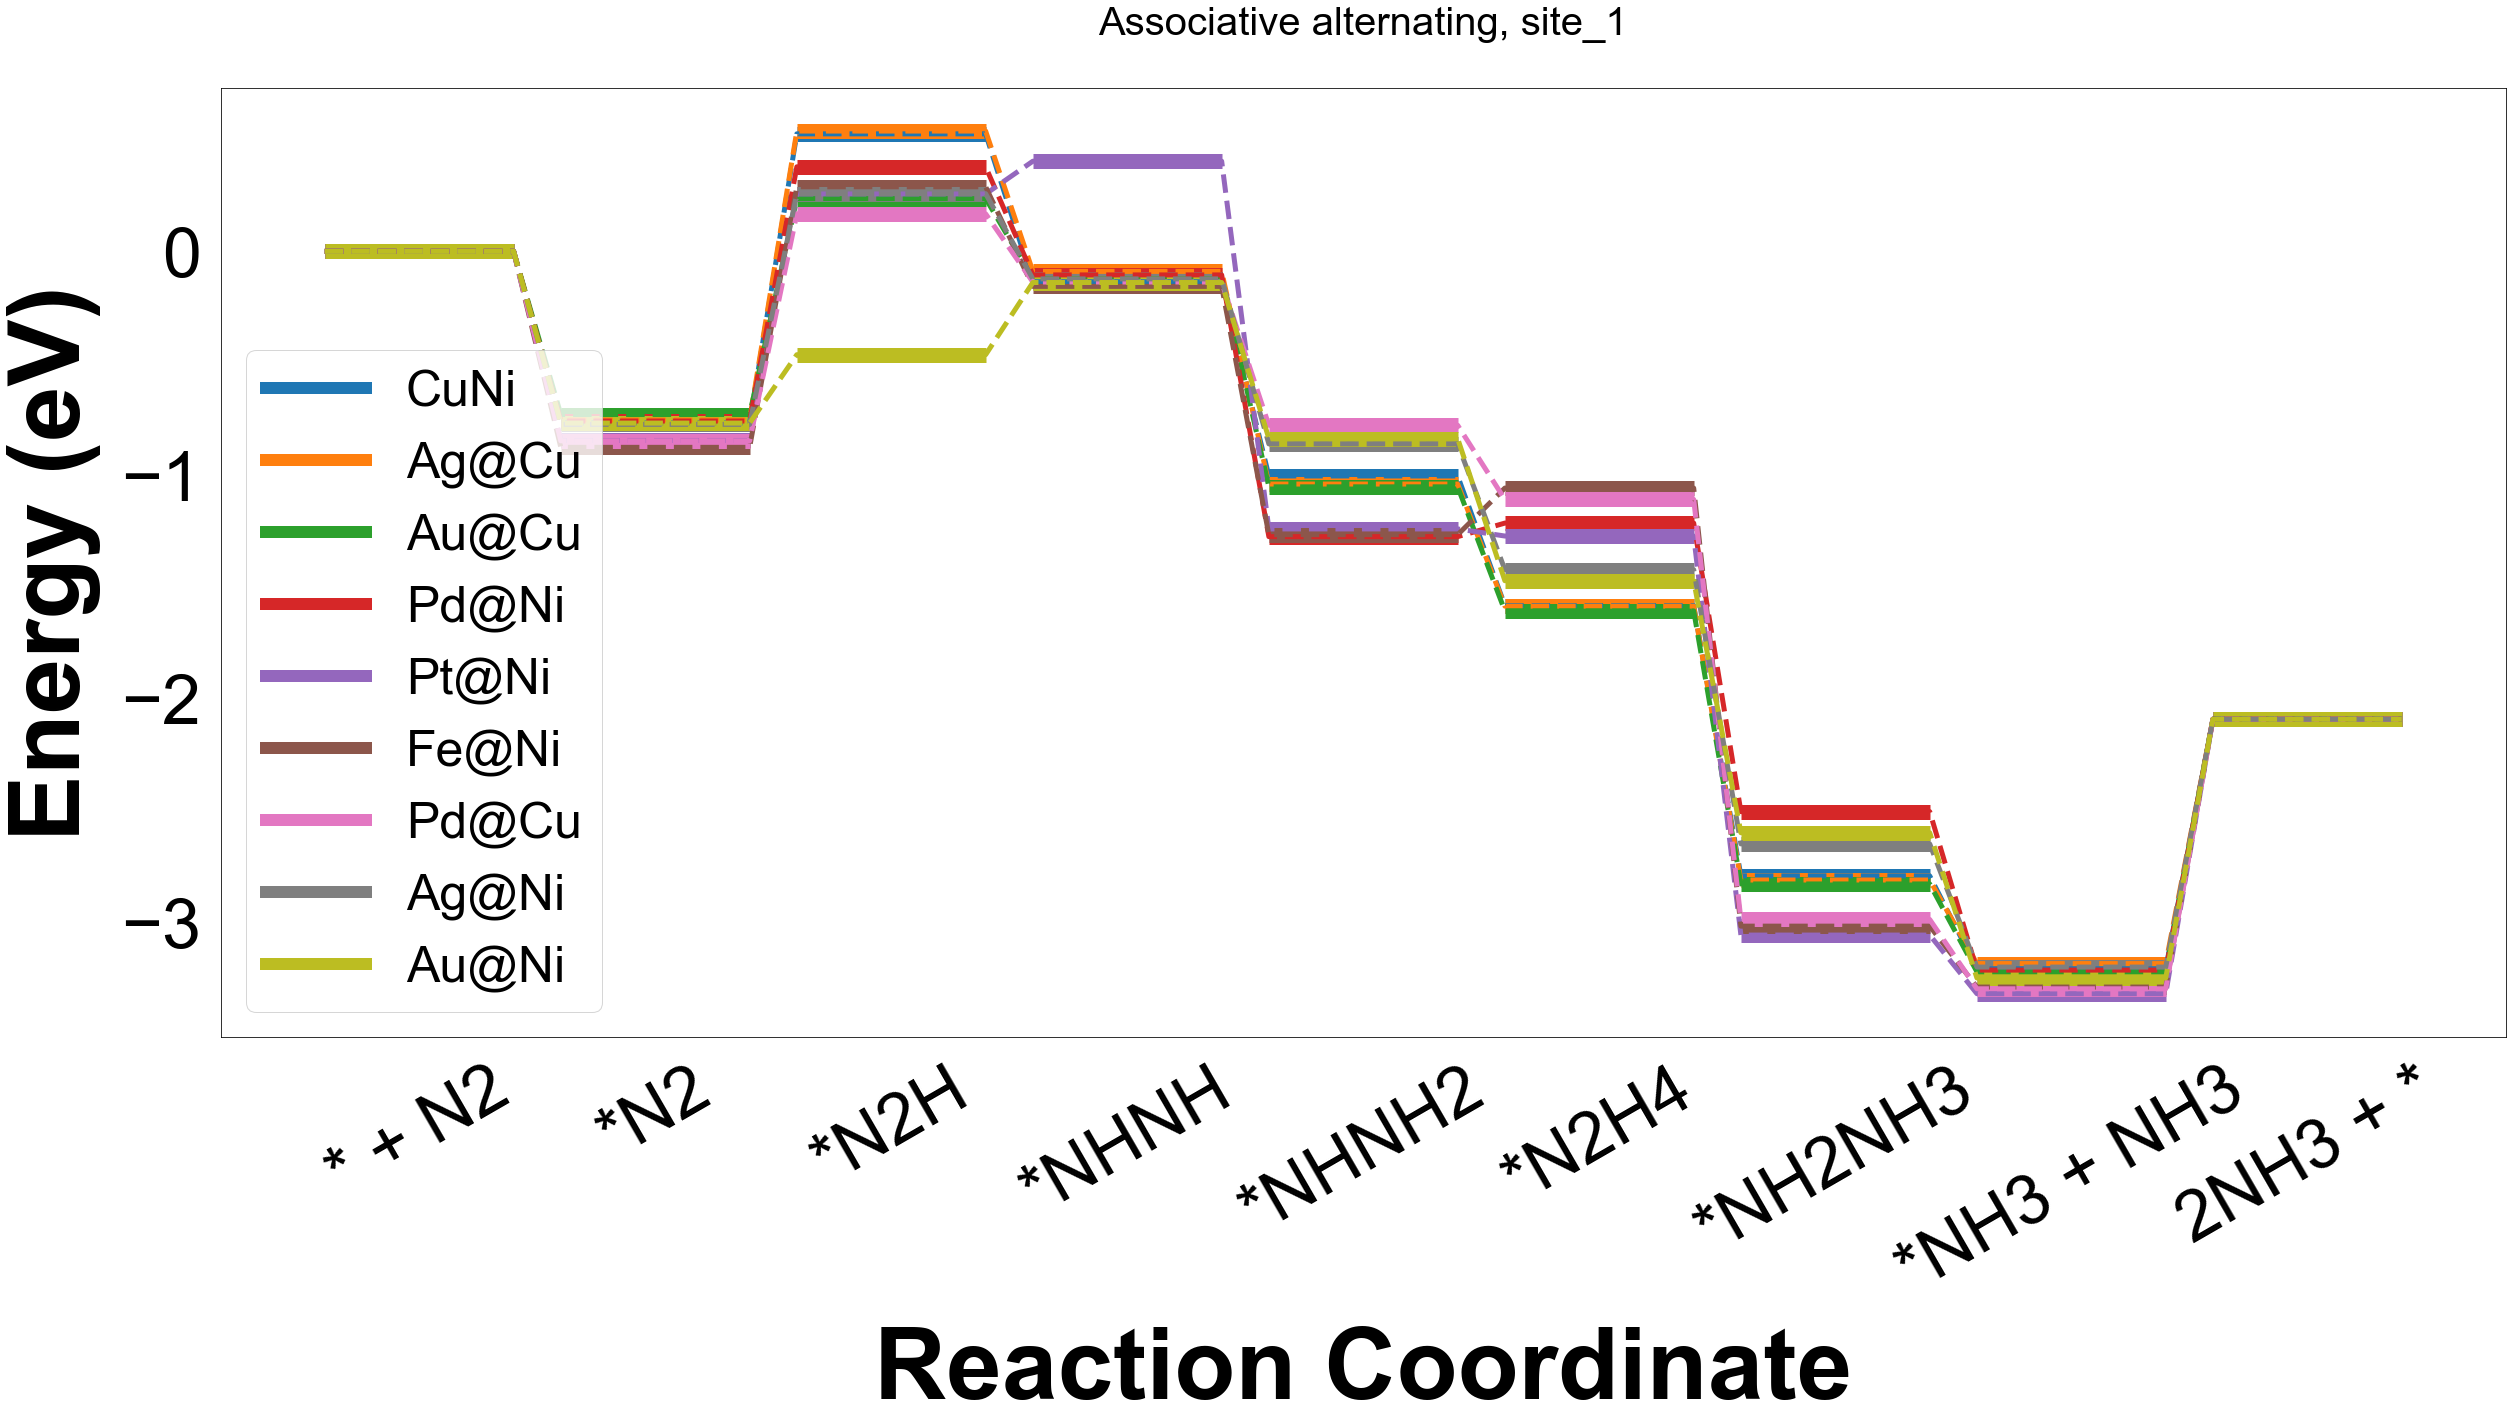

In [23]:
#'ad_site_number':['0:path_1', '1:test_path1', '2:path_1_xticks', '3:path_1_steps','4:barriers_path1']
site_number = 1
path = 'path_1'

dataset = df_dicts[f'ad_site_{site_number}'][path][0]
test_path = df_dicts[f'ad_site_{site_number}'][path][1]
path_ticks =  df_dicts[f'ad_site_{site_number}'][path][2]
graph_name = df_dicts[f'ad_site_{site_number}'][path][5]




systems = ['0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']
#colors = ['darkred','black','green','blue','indigo','darkgoldenrod','yellow','pink','olive']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
legends = ['CuNi','Ag@Cu','Au@Cu','Pd@Ni','Pt@Ni','Fe@Ni', 'Pd@Cu',
             'Ag@Ni','Au@Ni']
csfont = {'fontname':'Times New Roman'}
plt.rcParams["font.family"] = "Arial"

fig = plt.figure(figsize=(35,20))
ax = fig.add_subplot(111)
for i in range(0,len(systems)):
    ax.hlines(y = dataset[systems[i]][1],xmin=0,xmax=4,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][2],xmin=5,xmax=9,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][3],xmin=10,xmax=14,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][4],xmin=15,xmax=19,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][5],xmin=20,xmax=24,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][6],xmin=25,xmax=29,color=colors[i],lw=15,alpha=1)
    if path == 'path_1' or path == 'path_2':
        ax.hlines(y = dataset[systems[i]][7],xmin=30,xmax=34,color=colors[i],lw=15,alpha=1)
        ax.hlines(y = dataset[systems[i]][8],xmin=35,xmax=39,color=colors[i],lw=15,alpha=1)
        ax.hlines(y = dataset[systems[i]][9],xmin=40,xmax=44,color=colors[i],lw=15,alpha=1)
    ax.plot(test_path.index,test_path[systems[i]],ls='--',lw=5, color=colors[i],alpha=1)
plt.xticks(test_path.index,path_ticks,rotation=30)
#plt.xticks([])
ax.tick_params(axis=u'both', which=u'both',length=0,labelsize=70,pad=20)
#plt.legend(legends, prop = { "size": 24 }, loc ="upper right")
leg = plt.legend(legends, prop = { "size": 50 }, loc ="lower left")
for line in leg.get_lines():
    line.set_linestyle('-')
for legobj in leg.legendHandles:
    legobj.set_linewidth(12)
plt.ylabel('Energy (eV)',fontsize=100,weight='bold',labelpad=20)
plt.xlabel('Reaction Coordinate',fontsize=100,weight='bold',labelpad=20)
plt.title(f'{graph_name}, site_{site_number}',fontsize=40,y=1.05)
plt.tight_layout()
#plt.savefig(f'./{graph_name}.pdf',dpi=500)
plt.show()
    

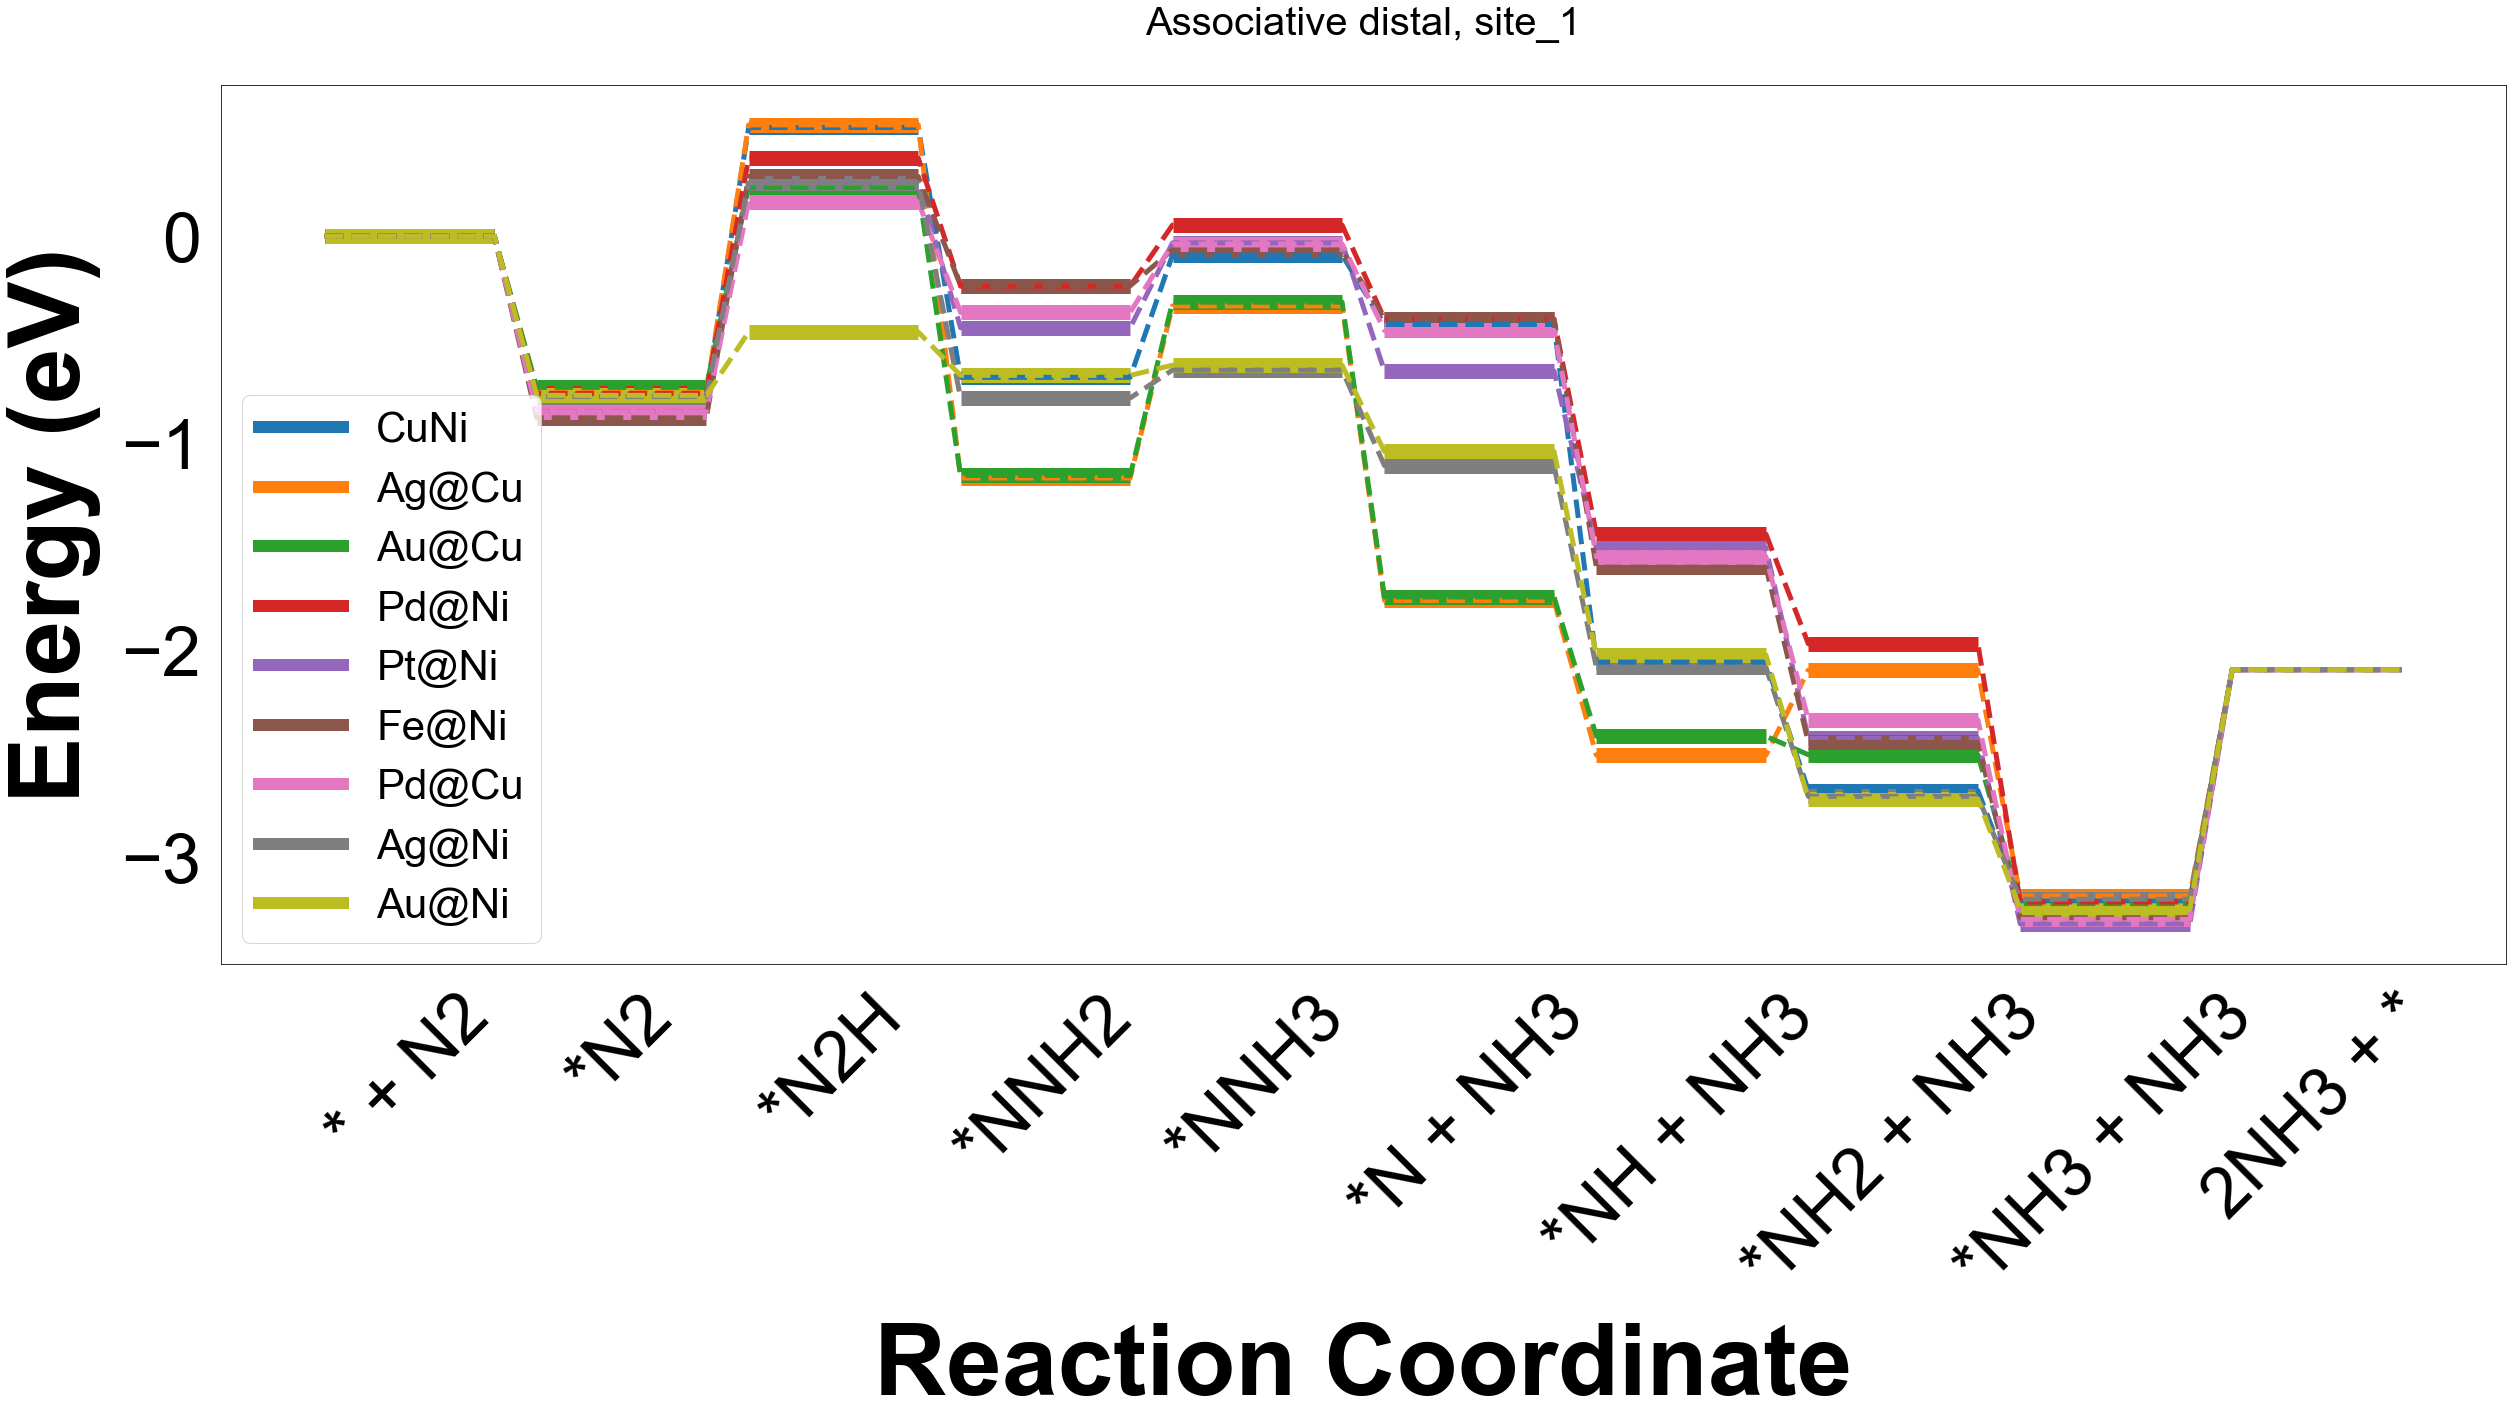

In [24]:
#'ad_site_number':['0:path_1', '1:test_path1', '2:path_1_xticks', '3:path_1_steps','4:barriers_path1']
site_number = 1
path = 'path_2'

dataset = df_dicts[f'ad_site_{site_number}'][path][0]
test_path = df_dicts[f'ad_site_{site_number}'][path][1]
path_ticks =  df_dicts[f'ad_site_{site_number}'][path][2]
graph_name = df_dicts[f'ad_site_{site_number}'][path][5]




systems = ['0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']
#colors = ['darkred','black','green','blue','indigo','darkgoldenrod','yellow','pink','olive']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
legends = ['CuNi','Ag@Cu','Au@Cu','Pd@Ni','Pt@Ni','Fe@Ni', 'Pd@Cu',
             'Ag@Ni','Au@Ni']
csfont = {'fontname':'Times New Roman'}
plt.rcParams["font.family"] = "Arial"

fig = plt.figure(figsize=(35,20))
ax = fig.add_subplot(111)
for i in range(0,len(systems)):
    ax.hlines(y = dataset[systems[i]][1],xmin=0,xmax=4,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][2],xmin=5,xmax=9,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][3],xmin=10,xmax=14,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][4],xmin=15,xmax=19,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][5],xmin=20,xmax=24,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][6],xmin=25,xmax=29,color=colors[i],lw=15,alpha=1)
    if path == 'path_1' or path == 'path_2':
        ax.hlines(y = dataset[systems[i]][7],xmin=30,xmax=34,color=colors[i],lw=15,alpha=1)
        ax.hlines(y = dataset[systems[i]][8],xmin=35,xmax=39,color=colors[i],lw=15,alpha=1)
        ax.hlines(y = dataset[systems[i]][9],xmin=40,xmax=44,color=colors[i],lw=15,alpha=1)
    ax.plot(test_path.index,test_path[systems[i]],ls='--',lw=5, color=colors[i],alpha=1)
plt.xticks(test_path.index,path_ticks,rotation=45)
#plt.xticks([])
ax.tick_params(axis=u'both', which=u'both',length=0,labelsize=70,pad=20)
#plt.legend(legends, prop = { "size": 24 }, loc ="upper right")
leg = plt.legend(legends, prop = { "size": 42 }, loc ="lower left")
for line in leg.get_lines():
    line.set_linestyle('-')
for legobj in leg.legendHandles:
    legobj.set_linewidth(12)
plt.ylabel('Energy (eV)',fontsize=100,weight='bold',labelpad=20)
plt.xlabel('Reaction Coordinate',fontsize=100,weight='bold',labelpad=20)
plt.title(f'{graph_name}, site_{site_number}',fontsize=40,y=1.05)
plt.tight_layout()
#plt.savefig(f'./{graph_name}.pdf',dpi=500)
plt.show()
    

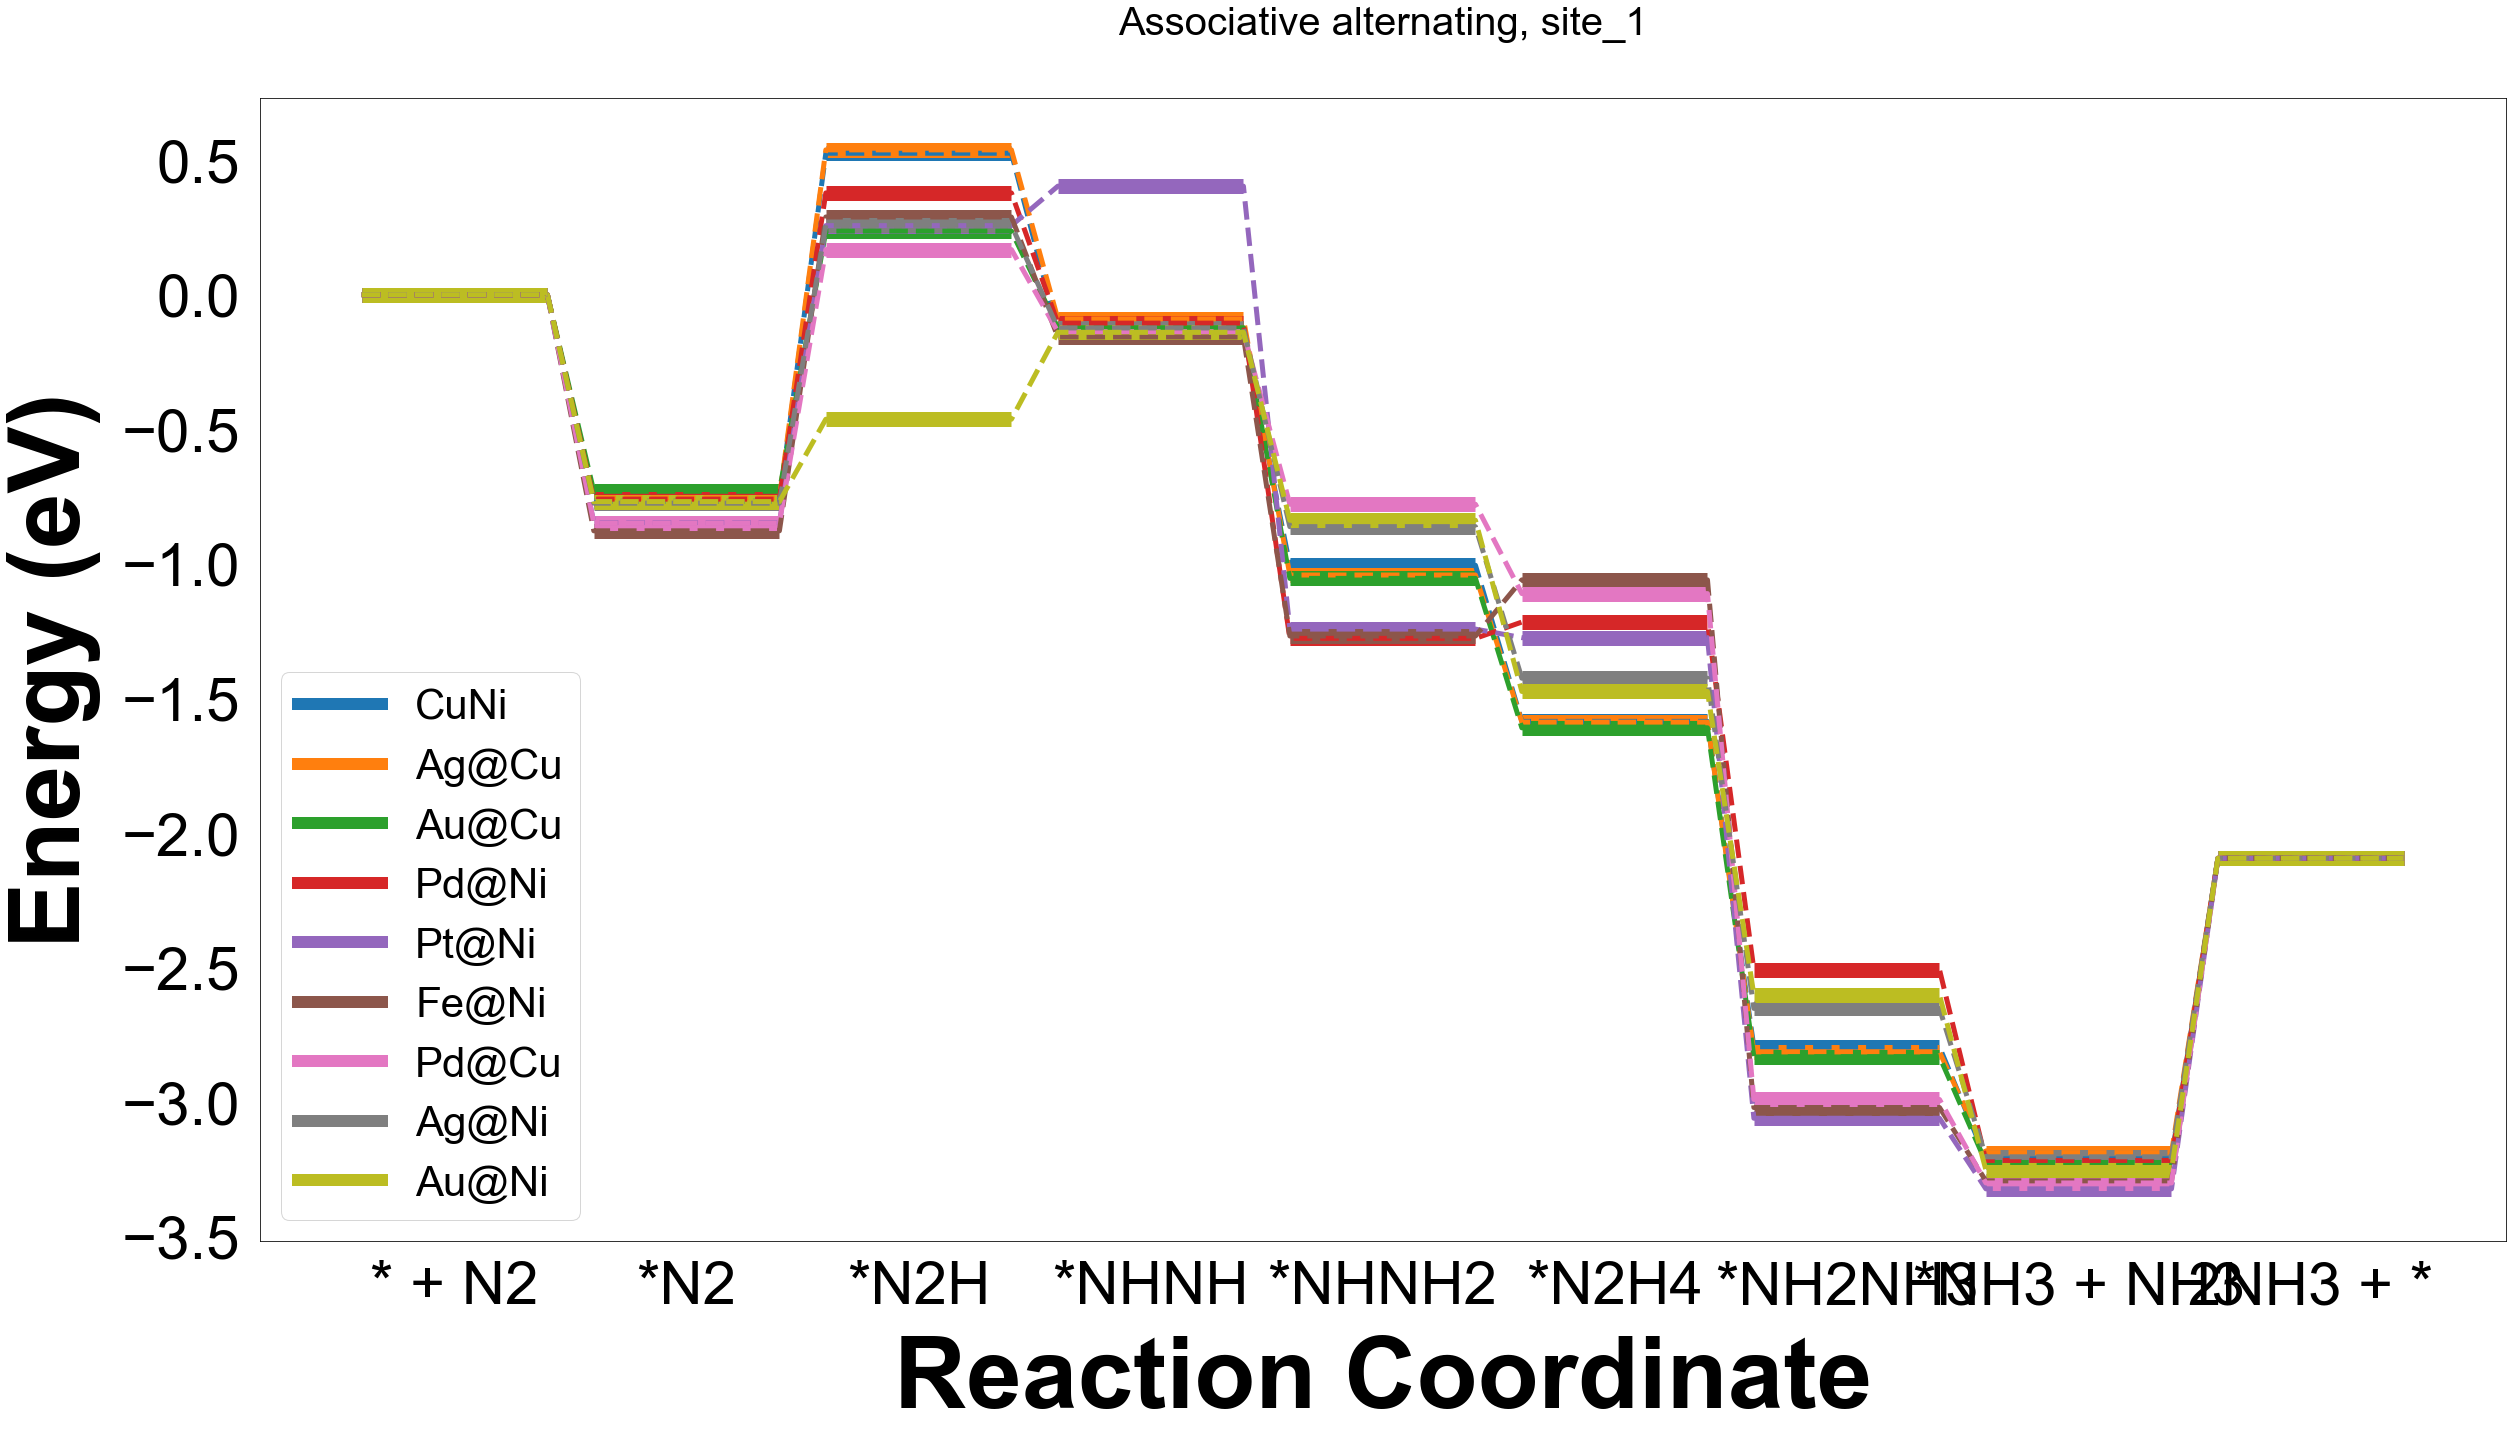

In [48]:
#'ad_site_number':['0:path_1', '1:test_path1', '2:path_1_xticks', '3:path_1_steps','4:barriers_path1']
site_number = 1
path = 'path_1'

dataset = df_dicts[f'ad_site_{site_number}'][path][0]
test_path = df_dicts[f'ad_site_{site_number}'][path][1]
path_ticks =  df_dicts[f'ad_site_{site_number}'][path][2]
graph_name = df_dicts[f'ad_site_{site_number}'][path][5]




systems = ['0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']
#colors = ['darkred','black','green','blue','indigo','darkgoldenrod','yellow','pink','olive']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
legends = ['CuNi','Ag@Cu','Au@Cu','Pd@Ni','Pt@Ni','Fe@Ni', 'Pd@Cu',
             'Ag@Ni','Au@Ni']
csfont = {'fontname':'Times New Roman'}
plt.rcParams["font.family"] = "Arial"

fig = plt.figure(figsize=(35,20))
ax = fig.add_subplot(111)
#ax.set_ylim(-1, 0.6)
for i in range(0,len(systems)):
    ax.hlines(y = dataset[systems[i]][1],xmin=0,xmax=4,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][2],xmin=5,xmax=9,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][3],xmin=10,xmax=14,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][4],xmin=15,xmax=19,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][5],xmin=20,xmax=24,color=colors[i],lw=15,alpha=1)
    ax.hlines(y = dataset[systems[i]][6],xmin=25,xmax=29,color=colors[i],lw=15,alpha=1)
    if path == 'path_1' or path == 'path_2':
        ax.hlines(y = dataset[systems[i]][7],xmin=30,xmax=34,color=colors[i],lw=15,alpha=1)
        ax.hlines(y = dataset[systems[i]][8],xmin=35,xmax=39,color=colors[i],lw=15,alpha=1)
        ax.hlines(y = dataset[systems[i]][9],xmin=40,xmax=44,color=colors[i],lw=15,alpha=1)
    ax.plot(test_path.index,test_path[systems[i]],ls='--',lw=5, color=colors[i],alpha=1)
plt.xticks(test_path.index,path_ticks,rotation=0)
#plt.xticks([])
ax.tick_params(axis=u'both', which=u'both',length=0,labelsize=60,pad=20)
#plt.legend(legends, prop = { "size": 24 }, loc ="upper right")
leg = plt.legend(legends, prop = { "size": 42 }, loc ="lower left")
for line in leg.get_lines():
    line.set_linestyle('-')
for legobj in leg.legendHandles:
    legobj.set_linewidth(12)
plt.ylabel('Energy (eV)',fontsize=100,weight='bold',labelpad=20)
plt.xlabel('Reaction Coordinate',fontsize=100,weight='bold',labelpad=20)
plt.title(f'{graph_name}, site_{site_number}',fontsize=40,y=1.05)
plt.tight_layout()
#plt.savefig(f'./{graph_name}.pdf',dpi=500)
plt.show()
    

In [55]:
path_1_df = df_dicts[f'ad_site_1']['path_1'][4]
path_1_df[['*N2H','2NH3 + *']].sort_values(by='*N2H')#(by=['*N2H','2NH3 + *'],ascending=[True, True])

,*N2,*N2H,*NHNH,*NHNH2,*N2H4,*NH2NH3,*NH3 + NH3,2NH3 + *
0_CuNi,-0.767459,1.293179,-0.661822,-0.869115,-0.579872,-1.209611,-0.415696,1.116656
1_Ag_subCu,-0.754606,1.292785,-0.627973,-0.951561,-0.54645,-1.225426,-0.373972,1.093465
2_Au_subCu,-0.73024,0.966621,-0.358794,-0.931442,-0.555138,-1.221914,-0.393042,1.13021
6_Pd_subNi,-0.759463,1.137665,-0.483722,-1.171197,0.060638,-1.291267,-0.709021,1.122627
7_Pt_subNi,-0.84642,1.103162,0.146567,-1.645586,-0.031715,-1.785642,-0.262295,1.228188
9_Fe_subNi,-0.877121,1.16594,-0.445636,-1.111081,0.208447,-1.96025,-0.272535,1.198496
11_Pd_subCu,-0.847855,1.015582,-0.304965,-0.64125,-0.331873,-1.879488,-0.310215,1.206324
13_Ag_subNi,-0.774378,1.032544,-0.381558,-0.738229,-0.563122,-1.22679,-0.551299,1.109092
14_Au_subNi,-0.768534,0.305977,0.323032,-0.698504,-0.63588,-1.127805,-0.649837,1.157812


In [57]:
path_2_df = df_dicts[f'ad_site_1']['path_2'][4]
path_2_df[['*N2H','2NH3 + *']].sort_values(by=['*N2H','2NH3 + *'],ascending=[True, True])

,*N2H,2NH3 + *
14_Au_subNi,0.305977,1.157812
2_Au_subCu,0.966621,1.13021
11_Pd_subCu,1.015582,1.206324
13_Ag_subNi,1.032544,1.109092
7_Pt_subNi,1.103162,1.228188
6_Pd_subNi,1.137665,1.122627
9_Fe_subNi,1.16594,1.198496
1_Ag_subCu,1.292785,1.093465
0_CuNi,1.293179,1.116656


In [62]:
path_3_df = df_dicts[f'ad_site_1']['path_3'][4]
path_3_df[['2N*','2NH3 + * ']].sort_values(by=['2N*','2NH3 + * '],ascending=[True, True])

,2N*,2NH3 + *
1_Ag_subCu,-0.712411,1.093465
2_Au_subCu,-0.695529,1.13021
13_Ag_subNi,-0.061192,1.109092
14_Au_subNi,0.007416,1.157812
7_Pt_subNi,0.396015,1.228188
11_Pd_subCu,0.592065,1.206324
0_CuNi,0.620702,1.116656
9_Fe_subNi,0.646214,1.198496
6_Pd_subNi,0.646835,1.122627


In [50]:
df_HER_barr = df_dicts[f'ad_site_1']['HER'][4]
df_HER_barr.sort_values(by='*H')

,*H,* + (1/2)H2
14_Au_subNi,-0.734733,0.734733
1_Ag_subCu,-0.734008,0.734008
13_Ag_subNi,-0.644583,0.644583
0_CuNi,-0.642175,0.642175
2_Au_subCu,-0.609587,0.609587
11_Pd_subCu,-0.507111,0.507111
9_Fe_subNi,-0.483422,0.483422
6_Pd_subNi,-0.47452,0.47452
7_Pt_subNi,-0.454242,0.454242


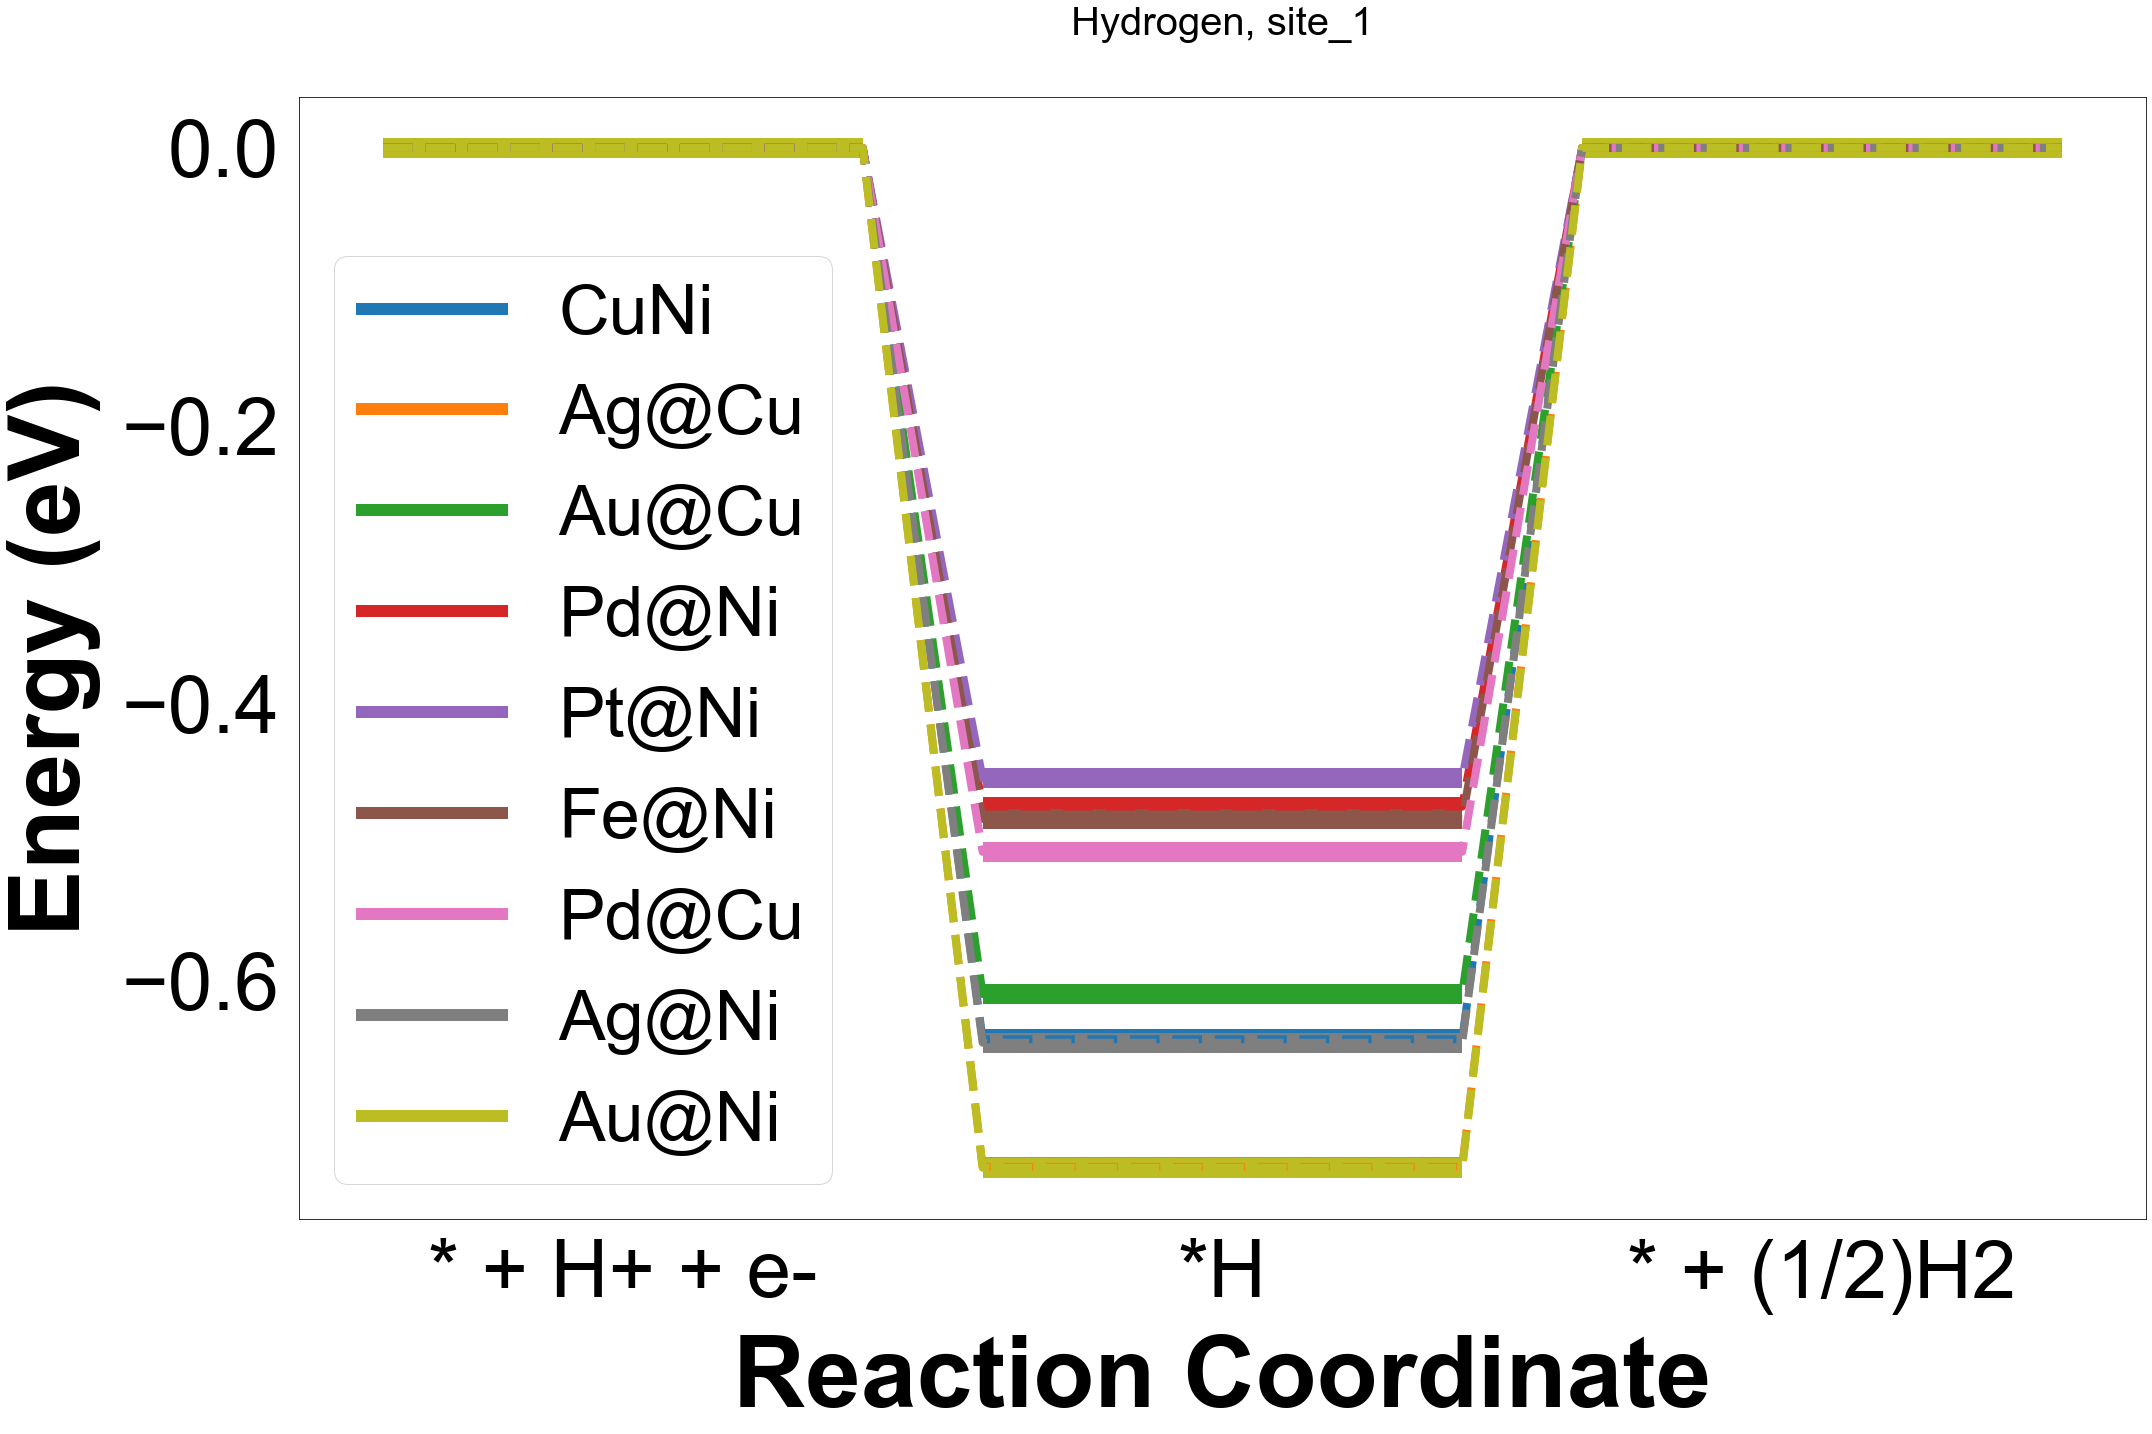

In [43]:
#'ad_site_number':['0:path_1', '1:test_path1', '2:path_1_xticks', '3:path_1_steps','4:barriers_path1']
site_number = 1
path = 'HER'

dataset = df_dicts[f'ad_site_{site_number}'][path][0]
test_path = df_dicts[f'ad_site_{site_number}'][path][1]
path_ticks =  df_dicts[f'ad_site_{site_number}'][path][2]
graph_name = df_dicts[f'ad_site_{site_number}'][path][5]




systems = ['0_CuNi','1_Ag_subCu','2_Au_subCu','6_Pd_subNi','7_Pt_subNi','9_Fe_subNi', '11_Pd_subCu',
             '13_Ag_subNi','14_Au_subNi']
#colors = ['darkred','black','green','blue','indigo','darkgoldenrod','yellow','pink','olive']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
legends = ['CuNi','Ag@Cu','Au@Cu','Pd@Ni','Pt@Ni','Fe@Ni', 'Pd@Cu',
             'Ag@Ni','Au@Ni']


csfont = {'fontname':'Times New Roman'}
plt.rcParams["font.family"] = "Arial"

line_width = 20

fig = plt.figure(figsize=(30,20))
#fig = plt.figure(figsize=(30,40))
ax = fig.add_subplot(111)
#ax.set_ylim(-0.8,-0.4)
#plt.ylim(-0.65,-0.3)
for i in range(0,len(systems)):
    ax.hlines(y = dataset[systems[i]][1],xmin=0,xmax=4,color=colors[i],lw=line_width,alpha=1)
    ax.hlines(y = dataset[systems[i]][2],xmin=5,xmax=9,color=colors[i],lw=line_width,alpha=1)
    ax.hlines(y = dataset[systems[i]][3],xmin=10,xmax=14,color=colors[i],lw=line_width,alpha=1)
    if path == 'path_1' or path == 'path_2':
        ax.hlines(y = dataset[systems[i]][7],xmin=30,xmax=34,color=colors[i],lw=line_width,alpha=1)
        ax.hlines(y = dataset[systems[i]][8],xmin=35,xmax=39,color=colors[i],lw=line_width,alpha=1)
        ax.hlines(y = dataset[systems[i]][9],xmin=40,xmax=44,color=colors[i],lw=line_width,alpha=1)
    ax.plot(test_path.index,test_path[systems[i]],ls='--',lw=8, color=colors[i],alpha=1)
plt.xticks(test_path.index,path_ticks,rotation=0)
ax.tick_params(axis=u'both', which=u'both',length=0,labelsize=80,pad=20)
#plt.legend(legends, prop = { "size": 24 }, loc ="upper right")
leg = plt.legend(legends, prop = { "size": 70 }, loc ="lower left")
for line in leg.get_lines():
    line.set_linestyle('-')
for legobj in leg.legendHandles:
    legobj.set_linewidth(12)
plt.ylabel('Energy (eV)',fontsize=100,weight='bold',labelpad=20)
plt.xlabel('Reaction Coordinate',fontsize=100,weight='bold',labelpad=20)
plt.title(f'{graph_name}, site_{site_number}',fontsize=40,y=1.05)
plt.tight_layout()

#plt.savefig(f'/Users/parastooagharezaei/Downloads/move_toPC/H2_analysis/{graph_name}.pdf',dpi=500)
plt.show()

In [63]:
HER_path = df_dicts['ad_site_1']['HER'][4]
HER_path.to_csv('./HER_path.csv',index=False)
HER_path

,*H,* + (1/2)H2
0_CuNi,-0.642175,0.642175
1_Ag_subCu,-0.734008,0.734008
2_Au_subCu,-0.609587,0.609587
6_Pd_subNi,-0.47452,0.47452
7_Pt_subNi,-0.454242,0.454242
9_Fe_subNi,-0.483422,0.483422
11_Pd_subCu,-0.507111,0.507111
13_Ag_subNi,-0.644583,0.644583
14_Au_subNi,-0.734733,0.734733


In [29]:
#Plotting the correlations
corr_df = df_1.corr()
import seaborn as sns
import numpy as np
sns.set(font_scale=1.9)
f, ax = plt.subplots(figsize=(20, 20))
mask=np.triu(np.ones_like(corr_df))
sns.heatmap(corr_df, cmap="coolwarm",annot=True,annot_kws={"size": 14},fmt=".2f",linewidth=0.5, mask=mask)
plt.tight_layout()
#plt.savefig('/Users/parastooagharezaei/Desktop/SVM_alloy_Eads/CuNi_adsites/correlation_matrix_v2.jpg',dpi=800,transparent=True)
plt.show()

NameError: name 'df_1' is not defined

In [30]:
my_df = df_adsE[df_adsE['ad_site_number']=='ad_site_1'].drop(['surf_energy','ad_site_number'],axis=1)
my_df = my_df.rename(columns={'0_N2':'N2', '2_N':'N', '3_N2H':'N2H', '4_NHNH':'NHNH', '5_NNH2':'NNH2', '6_NNH3':'NNH3',
                      '7_NH2NH':'NH2NH',
       '8_N2H4':'N2H4', '9_NH2':'NH2', '10_NH':'NH', '11_NH3':'NH3', '13_H':'H'})

In [35]:
my_df.columns

Index(['system', 'N2', 'N', 'N2H', 'NHNH', 'NNH2', 'NNH3', 'NH2NH', 'N2H4',
       'NH2', 'NH', 'NH3', 'H'],
      dtype='object')

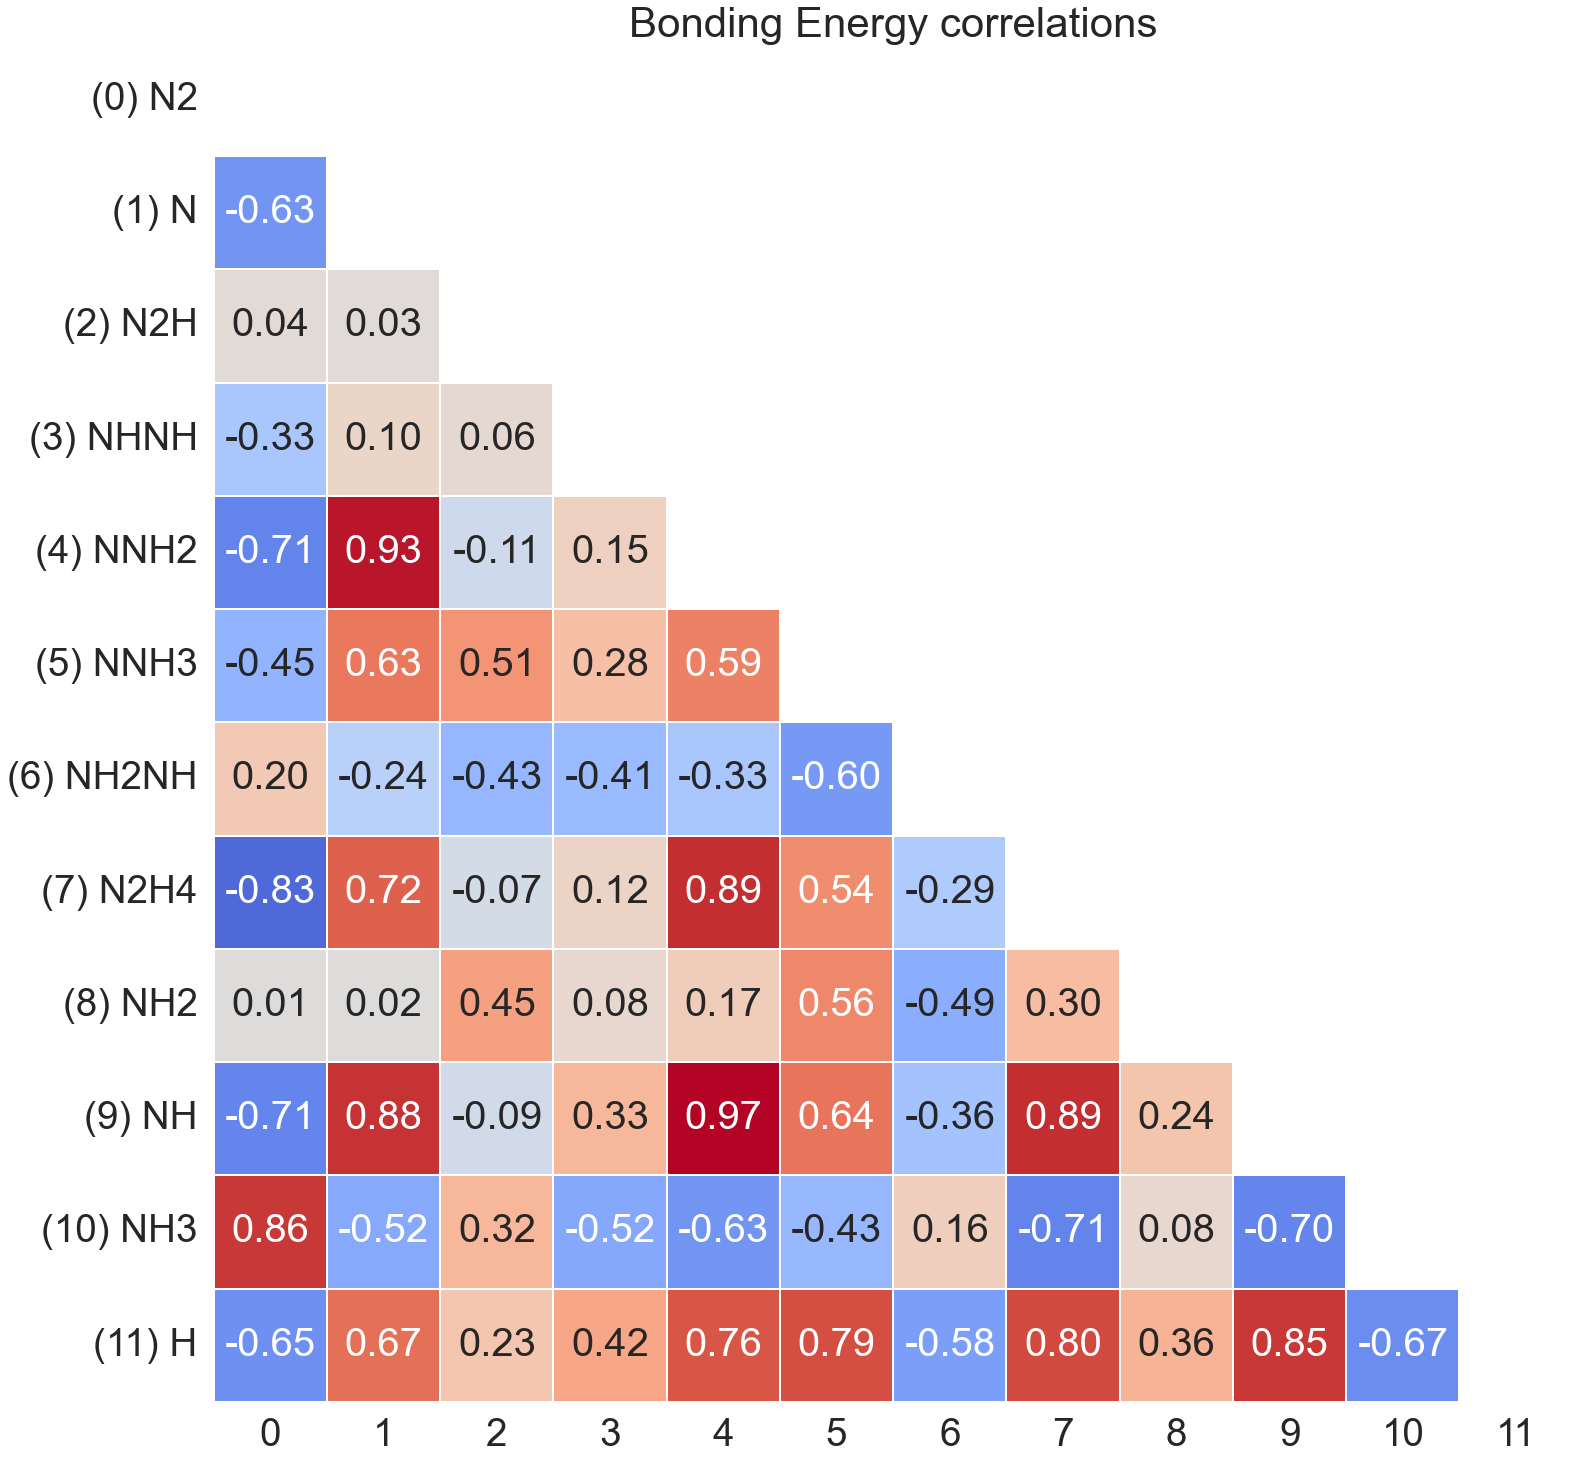

In [40]:


sns.set(font_scale=3.5)
sns.set_style('white')
keep_cols = list(my_df.columns)
df = my_df[keep_cols]
df_corr = df.corr()
yticklabels = [f'({col_ind}) {df_corr.columns[col_ind]}' for col_ind in range(len(df_corr.columns))]
xticklabels = list(range(0,len(df_corr.columns)))
mask = np.zeros_like(df_corr)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(25,25))
sns.heatmap(df_corr, center=0, cmap="coolwarm", annot=True, linewidths=0.3,linecolor='white',fmt='.2f',
           annot_kws={'size':40},mask=mask,square=True,cbar=False,
            xticklabels=xticklabels,yticklabels=yticklabels)
#plt.xticks(rotation=-10)
plt.title('Bonding Energy correlations')
#plt.savefig('./pearson_SOEs.pdf',bbox_inches='tight',dpi=500)
plt.show()


In [31]:
#plt.scatter(y = my_df.iloc[0][1:],x = my_df.columns[1:])

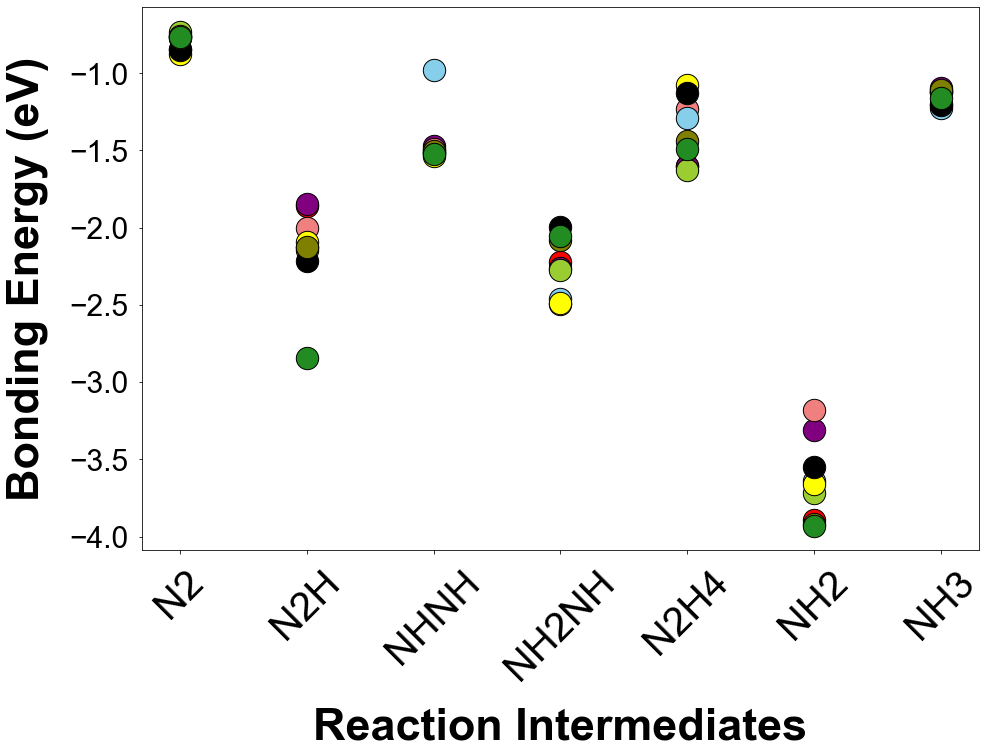

In [32]:
pylab.rcParams['xtick.major.pad']='10'
pylab.rcParams['ytick.major.pad']='10'

systems = ['CuNi',
          'Ag@Cu',
          'Au@Cu',
          'Pd@Ni',
          'Pt@Ni',
          'Fe@Ni',
          'Pd@Cu',
          'Ag@Ni',
          'Au@Ni']
colors_dict =   {'CuNi': 'red',
                 'Pd@Ni': 'lightcoral',
                 'Pd@Cu': 'black',
                 'Fe@Ni': 'yellow',
                 'Ag@Cu': 'purple',
                 'Ag@Ni': 'olive',
                 'Pt@Ni': 'skyblue',
                 'Au@Cu': 'yellowgreen',
                 'Au@Ni': 'forestgreen',
                 'Pt@Cu': 'red',
                 'Fe@Cu': 'indianred',
                 'Co@Ni': 'green',
                 'Co@Cu': 'sandybrown',
                 'Ru@Ni': 'blue',
                 'Ru@Cu': 'orange'}

ass_alt_xticks = ['N2','N2H','NHNH',
                'NH2NH',
                'N2H4','NH2', 'NH3']
ass_dist_xticks = ['N2','N2H','NNH2', 'NNH3','N','NH','NH2','NH3']
diss_xticks = ['N','NH','NH2','NH3']

my_cols = ass_alt_xticks
names_df = systems
markersize = 500
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)
#plt.ylim(-0.27, -0.20)

plot_0 = plt.scatter(y = my_df.iloc[0][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[0]), edgecolors='black')
plot_1 =plt.scatter(y = my_df.iloc[1][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[1]), edgecolors='black')
plot_2 =plt.scatter(y = my_df.iloc[2][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[2]), edgecolors='black')
plot_3 =plt.scatter(y = my_df.iloc[3][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[3]), edgecolors='black')
plot_4 =plt.scatter(y = my_df.iloc[4][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[4]), edgecolors='black')
plot_5 =plt.scatter(y = my_df.iloc[5][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[5]), edgecolors='black')
plot_6 =plt.scatter(y = my_df.iloc[6][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[6]), edgecolors='black')
plot_7 =plt.scatter(y = my_df.iloc[7][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[7]), edgecolors='black')
plot_8 =plt.scatter(y = my_df.iloc[8][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[8]), edgecolors='black')
plt.xticks(fontsize=40,rotation = +45)
#ax.tick_params(axis=u'both',which=u'both',length=0,labelsize=60,pad=20, reset=False)
#fit_line1 = plt.plot(x_line1,y_line1,color='red',linewidth=3)
#fit_line2 = plt.plot(x_line2,y_line2,color='red',linewidth=3)
#plt.legend(names_df[i])
#legend1 = plt.legend([plot_0, 
#                      plot_1, 
#                      plot_2,
#                      plot_3,
#                      plot_4, 
#                      plot_5, 
#                      plot_6,
#                      plot_7,
#                      plot_8], systems, prop = { "size": 18 }, loc ="upper left",scatterpoints=1)
#plt.legend((fit_line1,fit_line2), [(name1),(name2)], prop = { "size": 25 }, loc ="lower left",scatterpoints=1)
#plt.gca().add_artist(legend1)



plt.yticks(fontsize=30)
plt.ylabel('Bonding Energy (eV)',fontsize=45, labelpad=20,weight='bold')
plt.xlabel('Reaction Intermediates',fontsize=45, labelpad=20,weight='bold')
#plt.legend(names_df[i])
#plt.savefig('./ass_alt_corrs.pdf',bbox_inches='tight',dpi=500)
plt.show()


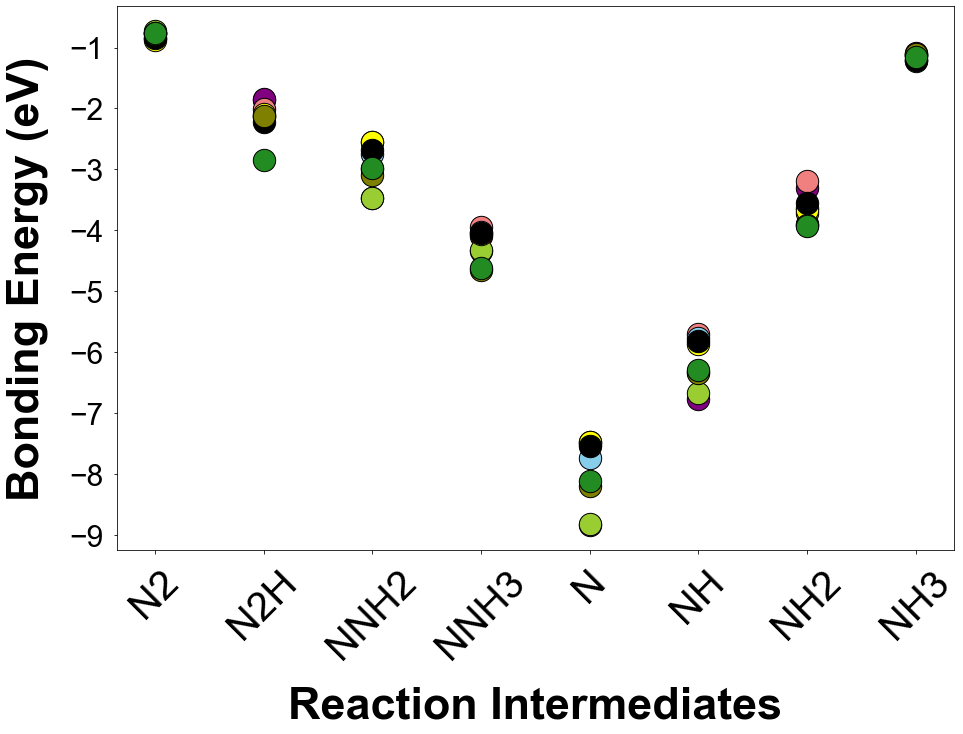

In [41]:
pylab.rcParams['xtick.major.pad']='10'
pylab.rcParams['ytick.major.pad']='10'

systems = ['CuNi',
          'Ag@Cu',
          'Au@Cu',
          'Pd@Ni',
          'Pt@Ni',
          'Fe@Ni',
          'Pd@Cu',
          'Ag@Ni',
          'Au@Ni']

colors_dict =   {'CuNi': 'red',
                 'Pd@Ni': 'lightcoral',
                 'Pd@Cu': 'black',
                 'Fe@Ni': 'yellow',
                 'Ag@Cu': 'purple',
                 'Ag@Ni': 'olive',
                 'Pt@Ni': 'skyblue',
                 'Au@Cu': 'yellowgreen',
                 'Au@Ni': 'forestgreen',
                 'Pt@Cu': 'red',
                 'Fe@Cu': 'indianred',
                 'Co@Ni': 'green',
                 'Co@Cu': 'sandybrown',
                 'Ru@Ni': 'blue',
                 'Ru@Cu': 'orange'}

ass_alt_xticks = ['N2','N2H','NHNH',
                'NH2NH',
                'N2H4','NH2', 'NH3']
ass_dist_xticks = ['N2','N2H','NNH2', 'NNH3','N','NH','NH2','NH3']
diss_xticks = ['N','NH','NH2','NH3']

my_cols = ass_dist_xticks
names_df = systems
markersize = 500
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)
#plt.ylim(-0.27, -0.20)

plot_0 = plt.scatter(y = my_df.iloc[0][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[0]), edgecolors='black')
plot_1 =plt.scatter(y = my_df.iloc[1][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[1]), edgecolors='black')
plot_2 =plt.scatter(y = my_df.iloc[2][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[2]), edgecolors='black')
plot_3 =plt.scatter(y = my_df.iloc[3][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[3]), edgecolors='black')
plot_4 =plt.scatter(y = my_df.iloc[4][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[4]), edgecolors='black')
plot_5 =plt.scatter(y = my_df.iloc[5][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[5]), edgecolors='black')
plot_6 =plt.scatter(y = my_df.iloc[6][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[6]), edgecolors='black')
plot_7 =plt.scatter(y = my_df.iloc[7][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[7]), edgecolors='black')
plot_8 =plt.scatter(y = my_df.iloc[8][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[8]), edgecolors='black')
plt.xticks(fontsize=40,rotation = +45)
#ax.tick_params(axis=u'both',which=u'both',length=0,labelsize=60,pad=20, reset=False)
#fit_line1 = plt.plot(x_line1,y_line1,color='red',linewidth=3)
#fit_line2 = plt.plot(x_line2,y_line2,color='red',linewidth=3)
#plt.legend(names_df[i])
#legend1 = plt.legend([plot_0, 
#                      plot_1, 
#                      plot_2,
#                      plot_3,
#                      plot_4, 
#                      plot_5, 
#                      plot_6,
#                      plot_7,
#                      plot_8], systems, prop = { "size": 18 }, loc ="upper left",scatterpoints=1)
#plt.legend((fit_line1,fit_line2), [(name1),(name2)], prop = { "size": 25 }, loc ="lower left",scatterpoints=1)
#plt.gca().add_artist(legend1)



plt.yticks(fontsize=30)
plt.ylabel('Bonding Energy (eV)',fontsize=45, labelpad=20,weight='bold')
plt.xlabel('Reaction Intermediates',fontsize=45, labelpad=20,weight='bold')
#plt.legend(names_df[i])
#plt.savefig('./ass_dist_corrs.pdf',bbox_inches='tight',dpi=500)
plt.show()


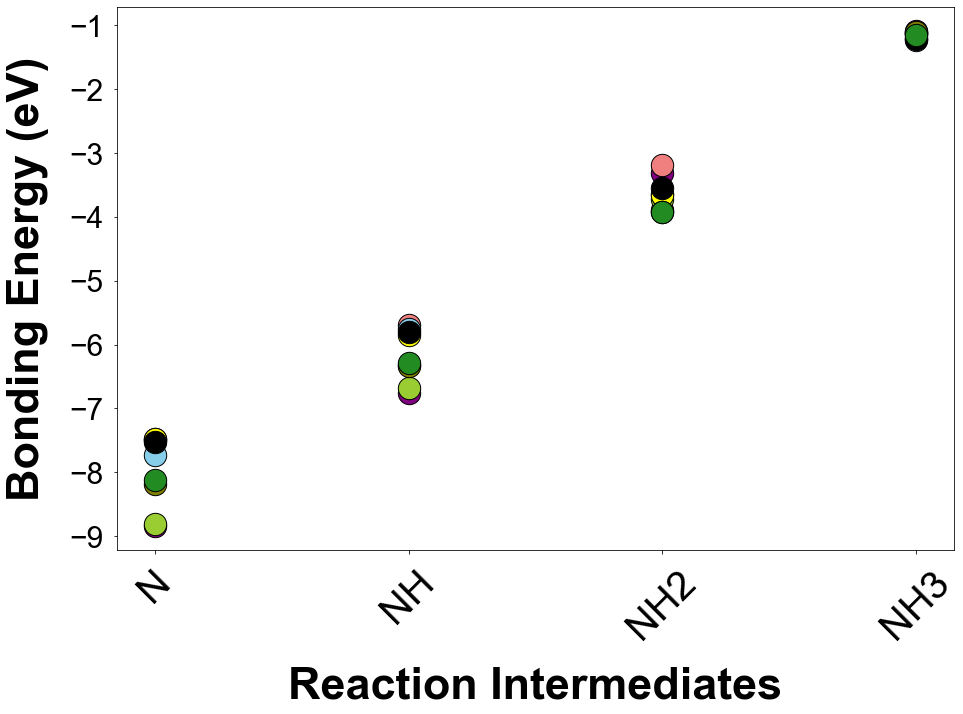

In [42]:
pylab.rcParams['xtick.major.pad']='10'
pylab.rcParams['ytick.major.pad']='10'

systems = ['CuNi',
          'Ag@Cu',
          'Au@Cu',
          'Pd@Ni',
          'Pt@Ni',
          'Fe@Ni',
          'Pd@Cu',
          'Ag@Ni',
          'Au@Ni']
colors_dict =   {'CuNi': 'red',
                 'Pd@Ni': 'lightcoral',
                 'Pd@Cu': 'black',
                 'Fe@Ni': 'yellow',
                 'Ag@Cu': 'purple',
                 'Ag@Ni': 'olive',
                 'Pt@Ni': 'skyblue',
                 'Au@Cu': 'yellowgreen',
                 'Au@Ni': 'forestgreen',
                 'Pt@Cu': 'red',
                 'Fe@Cu': 'indianred',
                 'Co@Ni': 'green',
                 'Co@Cu': 'sandybrown',
                 'Ru@Ni': 'blue',
                 'Ru@Cu': 'orange'}

ass_alt_xticks = ['N2','N2H','NHNH',
                #'NH2NH',
                'N2H4','NH2', 'NH3']
ass_dist_xticks = ['N2','N2H','NNH2', 'NNH3','N','NH','NH2','NH3']
diss_xticks = ['N','NH','NH2','NH3']

my_cols = diss_xticks
names_df = systems
markersize = 500
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)
#plt.ylim(-0.27, -0.20)

plot_0 = plt.scatter(y = my_df.iloc[0][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[0]), edgecolors='black')
plot_1 =plt.scatter(y = my_df.iloc[1][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[1]), edgecolors='black')
plot_2 =plt.scatter(y = my_df.iloc[2][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[2]), edgecolors='black')
plot_3 =plt.scatter(y = my_df.iloc[3][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[3]), edgecolors='black')
plot_4 =plt.scatter(y = my_df.iloc[4][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[4]), edgecolors='black')
plot_5 =plt.scatter(y = my_df.iloc[5][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[5]), edgecolors='black')
plot_6 =plt.scatter(y = my_df.iloc[6][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[6]), edgecolors='black')
plot_7 =plt.scatter(y = my_df.iloc[7][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[7]), edgecolors='black')
plot_8 =plt.scatter(y = my_df.iloc[8][my_cols],x =my_cols,marker = 'o',s = markersize, color = colors_dict.get(systems[8]), edgecolors='black')
plt.xticks(fontsize=40,rotation = +45)
#ax.tick_params(axis=u'both',which=u'both',length=0,labelsize=60,pad=20, reset=False)
#fit_line1 = plt.plot(x_line1,y_line1,color='red',linewidth=3)
#fit_line2 = plt.plot(x_line2,y_line2,color='red',linewidth=3)
#plt.legend(names_df[i])
#legend1 = plt.legend([plot_0, 
#                      plot_1, 
#                      plot_2,
#                      plot_3,
#                      plot_4, 
#                      plot_5, 
#                      plot_6,
#                      plot_7,
#                      plot_8], systems, prop = { "size": 18 }, loc ="upper left",scatterpoints=1)
#plt.legend((fit_line1,fit_line2), [(name1),(name2)], prop = { "size": 25 }, loc ="lower left",scatterpoints=1)
#plt.gca().add_artist(legend1)



plt.yticks(fontsize=30)
plt.ylabel('Bonding Energy (eV)',fontsize=45, labelpad=20,weight='bold')
plt.xlabel('Reaction Intermediates',fontsize=45, labelpad=20,weight='bold')
#plt.legend(names_df[i])
#plt.savefig('./diss_corrs.pdf',bbox_inches='tight',dpi=500)
plt.show()


In [44]:
dopants = ['CuNi',
            'Pd@Ni',
            'Pd@Cu',
            'Fe@Ni',
            'Ag@Cu',
            'Ag@Ni',
            'Pt@Ni',
            'Au@Cu',
            'Au@Ni',
            'Pt@Cu',
            'Fe@Cu',
            'Co@Ni',
            'Co@Cu',
            'Ru@Ni',
            'Ru@Cu']
charges = [-0.02,
    -0.3223999999999982,
 -0.3326999999999991,
 0.3732000000000006,
 -0.1198000000000014,
 -0.1099999999999994,
 -0.5869,
 -0.4458000000000002,
 -0.4376999999999995,
 -0.5977999999999994,
 0.3903999999999996,
 0.1296999999999997,
 0.1365000000000016,
 -0.0805000000000006,
 -0.0720999999999989]
dopant_charges = [(dopants[i], charges[i]) for i in range(len(charges))]
dopant_charges
dict_dop_charge = {}
for i in dopant_charges:
    dict_dop_charge[i[0]] = i[1]
    
systems = ['CuNi',
          'Ag@Cu',
          'Au@Cu',
          'Pd@Ni',
          'Pt@Ni',
          'Fe@Ni',
          'Pd@Cu',
          'Ag@Ni',
          'Au@Ni']

names_df = ['CuNi',
            'Pd@Ni',
            'Pd@Cu',
            'Fe@Ni',
            'Ag@Cu',
            'Ag@Ni',
            'Pt@Ni',
            'Au@Cu',
            'Au@Ni',
            'Pt@Cu',
            'Fe@Cu',
            'Co@Ni',
            'Co@Cu',
            'Ru@Ni',
            'Ru@Cu']

electronegs = [0,
    0.2945000000000002,
 0.2945000000000002,
 -0.0754999999999999,
 0.024499999999999966,
 0.024499999999999966,
 0.37449999999999983,
 0.6345000000000001,
 0.6345000000000001,
 0.37449999999999983,
 -0.0754999999999999,
 -0.025500000000000078,
 -0.025500000000000078,
 0.2945000000000002,
 0.2945000000000002]

electroneg_dict = {}
for i in range(len(names_df)):
    electroneg_dict[names_df[i]] = electronegs[i]
    
#electroneg_dict



In [45]:
new_systems = ['CuNi',
              'CuNi',
              'Ag@Cu',
               'Ag@Cu',
              'Au@Cu',
               'Au@Cu',
              'Pd@Ni',
               'Pd@Ni',
              'Pt@Ni',
               'Pt@Ni',
              'Fe@Ni',
               'Fe@Ni',
              'Pd@Cu',
               'Pd@Cu',
              'Ag@Ni',
               'Ag@Ni',
              'Au@Ni',
              'Au@Ni']
df_adsE = pd.read_csv('/Users/parastooagharezaei/Downloads/copied_all_mols_reactions_path/df_adsE.csv')
df_adsE['new_system_name'] = new_systems
df_adsE['electroneg_diff'] = [electroneg_dict[i] for i in list(df_adsE['new_system_name'])]
df_adsE['dopant_charge'] = [dict_dop_charge[i] for i in list(df_adsE['new_system_name'])]

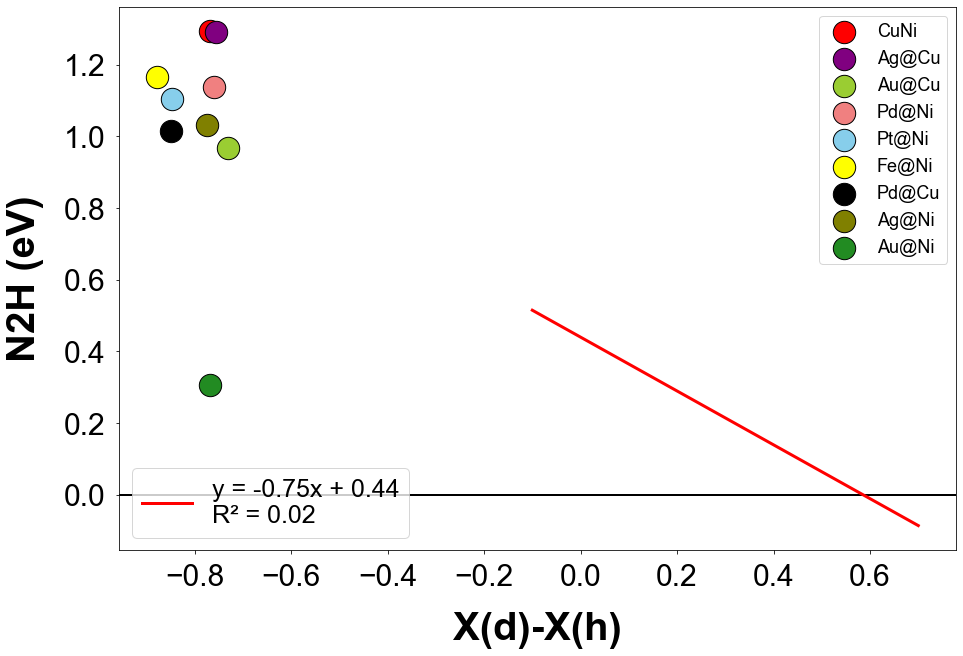

In [47]:
df = df_adsE[df_adsE['ad_site_number']=='ad_site_1']

systems = ['CuNi',
          'Ag@Cu',
          'Au@Cu',
          'Pd@Ni',
          'Pt@Ni',
          'Fe@Ni',
          'Pd@Cu',
          'Ag@Ni',
          'Au@Ni']

colors_dict =   {'CuNi': 'red',
                 'Pd@Ni': 'lightcoral',
                 'Pd@Cu': 'black',
                 'Fe@Ni': 'yellow',
                 'Ag@Cu': 'purple',
                 'Ag@Ni': 'olive',
                 'Pt@Ni': 'skyblue',
                 'Au@Cu': 'yellowgreen',
                 'Au@Ni': 'forestgreen',
                 'Pt@Cu': 'red',
                 'Fe@Cu': 'indianred',
                 'Co@Ni': 'green',
                 'Co@Cu': 'sandybrown',
                 'Ru@Ni': 'blue',
                 'Ru@Cu': 'orange'}

cols = [ '0_N2', 
        '2_N', 
        '3_N2H',
       '4_NHNH', 
        '5_NNH2', 
        '9_NH2', 
        '10_NH', 
        '11_NH3', 
        '13_H']

x_ = list(df['0_N2'])
#print(x_)
pylab.rcParams['xtick.major.pad']='10'
pylab.rcParams['ytick.major.pad']='10'

names_df = systems
#y_ = list(df['Nmin']+df['Nmax'])# + df['Nmin'] + df['H']) #dopant_charge
#y_ = list(df[cols[2]])
y_ = list(df_p1_s1['*N2H'])
colors = [colors_dict[i] for i in systems]
#number = 13
#cmap = plt.get_cmap('gnuplot')
#colors = [cmap(i) for i in np.linspace(0, 1, number)]


#Find the best line fitting the electro and charge:
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x_, y_)
r2 = r_value**2

x_line = [-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7] #electroneg
#x_line = [-0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7] #dopant_charge
y_line = [(slope*i)+ intercept for i in x_line]
name = f'y = {round(slope,2)}x + {round(intercept,2)}' + '\n' + unicodeit.replace(f'R^2 = {round(r2,2)}')
#print(name)


markersize = 500
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)
#plt.ylim(-0.27, -0.20)

#for i in range(len(x_)):
plot_0 = plt.scatter(x_[0],y_[0], marker = 'o',s = markersize, color = colors[0], edgecolors='black') #_,color=colors,edgecolor='black',linewidth=4, width=0.6)
plot_1 =plt.scatter(x_[1],y_[1], marker = 'o',s = markersize, color = colors[1], edgecolors='black')
plot_2 =plt.scatter(x_[2],y_[2], marker = 'o',s = markersize, color = colors[2], edgecolors='black')
plot_3 =plt.scatter(x_[3],y_[3], marker = 'o',s = markersize, color = colors[3], edgecolors='black')
plot_4 =plt.scatter(x_[4],y_[4], marker = 'o',s = markersize, color = colors[4], edgecolors='black')
plot_5 =plt.scatter(x_[5],y_[5], marker = 'o',s = markersize, color = colors[5], edgecolors='black')
plot_6 =plt.scatter(x_[6],y_[6], marker = 'o',s = markersize, color = colors[6], edgecolors='black')
plot_7 =plt.scatter(x_[7],y_[7], marker = 'o',s = markersize, color = colors[7], edgecolors='black')
plot_8 =plt.scatter(x_[8],y_[8], marker = 'o',s = markersize, color = colors[8], edgecolors='black')
plt.axhline(0, color='black',linewidth=2)
fit_line = plt.plot(x_line,y_line,color='red',linewidth=3)
#plt.legend(names_df[i])
legend1 = plt.legend([plot_0, plot_1, plot_2,plot_3,
           plot_4, plot_5, plot_6,plot_7,
           plot_8], names_df, prop = { "size": 18 }, loc ="upper right",scatterpoints=1)
plt.legend((fit_line), [(name)], prop = { "size": 25 }, loc ="lower left",scatterpoints=1)
plt.gca().add_artist(legend1)
plt.xticks(fontsize=30) #,rotation = +90)
plt.yticks(fontsize=30)
plt.ylabel('N2H (eV)',fontsize=40, labelpad=20,weight='bold')
plt.xlabel('X(d)-X(h)',fontsize=40, labelpad=20,weight='bold')
#plt.legend(names_df[i])
plt.savefig('./trash.pdf',bbox_inches='tight',dpi=500)
plt.show()
            

In [17]:
df_p1_s1

4